# Lab 01：從原始輪詢資料到分析特徵

## 問題與資料

Lab 00 把 `detector.py` 的 `rolling_zscore()` 接上即時流量，比較了三種視窗長度。這一節我們改用有 Ground Truth Events 標記的資料，以便於驗證結果。

本實驗使用一份 30 天的歷史資料：5 個 Port 的 SNMP 介面計數，取樣間隔 300 秒（共 43,200 列），內含 10 個事件（18 個獨立的事件×Port 時窗）。

> **環境設定：** 所有分析都在 Notebook 內完成，讀取 `data/synthetic/` 路徑下的 CSV 檔。不需要啟動 Prometheus、node_exporter、Grafana 或 `detector.py`。若 Lab 00 的服務仍在執行，直接關閉即可。

資料集裡有 10 個標記的 event（A 到 J），以及一份 change calendar。**計畫性變更在流量上與真實事故長得一模一樣**，必須被抑制而不是被偵測到。`event_id` 與 `event_label` 兩欄是 ground truth，只用來評分，不用來擬合。

原始欄位全部是 300 秒區間內的總量，不是累積 counter：

| 欄位 | 意義 | 角色 |
|---|---|---|
| `timestamp` | 輪詢時間，5 分鐘一次 | index |
| `device_id`, `port_id`, `port_role` | 哪一個介面，以及它的功能 | grouping key |
| `INOCTETS`, `OUTOCTETS` | 進 / 出 bytes | throughput |
| `INUCASTPKTS`, `OUTUCASTPKTS` | unicast 封包，進 / 出 | packet rate |
| `INNUCASTPKTS`, `OUTNUCASTPKTS` | non-unicast 封包，進 / 出 | packet rate |
| `INBROADCASTPKTS`, `OUTBROADCASTPKTS` | broadcast 封包 | L2 storm 的訊號 |
| `INMULTICASTPKTS`, `OUTMULTICASTPKTS` | multicast 封包 | flooding 的訊號 |
| `INERRORS`, `OUTERRORS` | frame error | link quality |
| `INDISCARDS`, `OUTDISCARDS` | 被丟棄的 frame | congestion |
| `INUNKNOWNPROTOS` | 無法辨識協定的 frame | scan 或設定錯誤 |
| `event_label`, `event_id` | 注入 event 的 ground truth | 只用於評分 |

`ERRORS` 與 `DISCARDS` 的區別要分清楚。前者是傳輸失敗，屬於硬體或線路層；後者是傳輸成功但被設備主動丟棄，屬於軟體或資源層。

## 這一節在整條 pipeline 的哪裡

課程投影片把原始資料到告警畫成八個方格。這兩本 lab 涵蓋第 4 格到第 8 格，本節做完前四格，Lab 02 做最後一格。

| 方格 | 名稱 | 在哪裡 |
|---|---|---|
| 4 | 去重、排序、缺值與雜訊處理 | 本節第 2 到 4 步 |
| 5 | 重採樣與時間窗聚合 | 本節第 5 步 |
| 6 | Lag／Rolling／Trend／Seasonality 特徵 | 本節第 6 到 11 步 |
| 7 | 特徵品質檢查與版本化 | 本節第 12 到 16 步 |
| 8 | 異常偵測模型／Dashboard／Alert Rule | Lab 02 全部 |

每一步的形狀相同：先說這一步在問什麼，跑出圖，看圖上暴露了什麼缺口，那個缺口就是下一步存在的理由。結尾的探索練習都是換一種設計再執行一次，答案不在文字裡，在你重新執行之後的那張圖上。

本節的產出是 `outputs/workshop/features.csv` 與 `outputs/workshop/feature_spec.json`，兩份一起交給 Lab 02。

| 步驟 | 大綱 |
|---|---|
| 1 | 載入 telemetry 與 ground truth |
| 2 | 去重、排序與鍵值唯一性 |
| 3 | 缺值與時間軸完整性 |
| 4 | 雜訊處理：平滑要付的價錢 |
| 5 | 重採樣與時間窗聚合 |
| 6 | counter 轉成兩類 feature：volume 與 shape |
| 7 | scale profile：為什麼單一全域 threshold 必然錯 |
| 8 | zero-value profile：哪些欄位撐不起 z-score |
| 9 | distribution：z-score 在這一欄可信嗎 |
| 10 | autocorrelation：rolling window 長度的下限 |
| 11 | rolling baseline 與 robust z |
| 12 | feature correlation：哪兩欄是高相關 |
| 13 | event × feature heatmap：每個 feature 的盲點 |
| 14 | leave-one-out ablation 與 greedy forward selection |
| 15 | anomaly taxonomy |
| 16 | 存檔與 feature spec 版本化 |


## 這本 notebook 怎麼讀

**從上往下、一格一格執行**，不要跳格。後面的格子用的是前面算出來的變數，跳過任何一格都會出現 `NameError`。整本重新執行一次大約 1 到 2 分鐘。

每一步都是同一個循環，只是內容不同：

1. 一段文字說這一步在問什麼
2. 一格程式，做那件事並且畫圖
3. 圖下面一小段，說圖上看到了什麼、以及它為什麼逼出下一步
4. 一段**探索練習**，把某個參數換掉再執行一次。答案不在文字裡，在你重新執行之後的那張圖上

從第 11 步開始，每建立一個新方法就會呼叫一次 `rollout()`，然後畫一張固定格式的偵測結果圖。那張圖固定三格：

| 格 | 看什麼 |
|---|---|
| A | 原始訊號，紅點是這個方法真的發出告警的位置，橘色區塊是真實發生過 event 的時段 |
| B | 這個方法算出來的分數、門檻線，以及通過「連續 N 筆」確認的區段 |
| C | 整個月 18 個 event window，綠色抓到、紅色漏掉，加上每天產生幾筆告警 |

紅點落在橘色區塊裡是好事，落在外面就是誤報。**A 格是新手最該先看的一格**，因為它把「這個方法行不行」從一個數字變成一件看得見的事。

每次 `rollout()` 都會把成績記進一份 ledger，Lab 02 會接著往同一份裡加。第 16 步與 Lab 02 結尾各畫一次 `plot_ledger()`，那張圖上一個方法要往左上方移動才算有貢獻。

### 先認識幾個名詞

| 名詞 | 在這門課裡的意思 |
|---|---|
| **event** | 資料裡標好的一段真實異常時段。18 個，其中 2 個是計畫性變更 |
| **incident** | 必須抓到的 event，16 個。計畫性變更不算，因為對它保持安靜才是對的 |
| **baseline** | 「正常長什麼樣」的估計值，通常是一個 center 加一個 scale |
| **score** | 這一筆離 baseline 多遠，連續數值，沒有立場 |
| **label** | score 跨過門檻並且連續 N 筆，才算數 |
| **alert** | label 再通過維運條件之後，真的送到人手上的那一則 |
| **recall** | 18 個 window 裡抓到幾個。一個 window 抓到一次就算 |
| **labels per day** | 每天在沒有 event 的時段發出幾筆。值班的人實際承受的量 |
| **degenerate** | 大半時間等於零的欄位，z-score 在上面沒有意義 |

`z`、`window`、`cadence` 這些字第一次用到的時候會在當場解釋。

In [1]:
from pathlib import Path
from collections import namedtuple
import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import matplotlib.font_manager as fm

# Latin glyphs come from a serif face, CJK glyphs fall back to whatever this machine has.
# matplotlib walks this list per glyph, so one list covers both scripts on all three platforms.
_HAVE = {f.name for f in fm.fontManager.ttflist}
_LATIN = [f for f in ("Georgia", "Times New Roman", "DejaVu Serif") if f in _HAVE]
_CJK = [f for f in ("Heiti TC", "PingFang TC", "PingFang HK", "Songti TC", "LiHei Pro",
                    "Microsoft JhengHei", "Noto Sans CJK TC", "Source Han Sans TC",
                    "Arial Unicode MS", "WenQuanYi Zen Hei") if f in _HAVE]
if not _CJK:
    print("找不到任何中文字型，圖上的中文會變成方框。macOS 內建 Heiti TC，"
          "Linux 請安裝 fonts-noto-cjk，Windows 用 Microsoft JhengHei。")

plt.rcParams.update({
    "font.family": (_LATIN + _CJK) or ["DejaVu Sans"],
    "axes.unicode_minus": False,          # the CJK faces have no U+2212, so use a plain hyphen
    "figure.dpi": 110, "axes.titlesize": 10, "axes.titlelocation": "left",
    "axes.labelsize": 9, "legend.fontsize": 8, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# Walk up from the working directory until we find the course root. The marker is
# the environments/ folder, so the notebook runs from any launch directory.
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "environments").is_dir():
    ROOT = ROOT.parent
DATA = ROOT / "data" / "synthetic"
OUT = ROOT / "outputs" / "workshop"
OUT.mkdir(parents=True, exist_ok=True)

# One colour means one thing across every figure in both labs: blue is the measured
# signal, orange the baseline, purple a derived score, red an alert or a limit.
C = {"signal": "#3B7DD8", "baseline": "#E0752D", "score": "#7A5AC7",
     "alert": "#D6455D", "truth": "#FF9F1C", "peer": "#2E9E7B", "muted": "#9AA4B0"}

# Rescales the median absolute deviation so that, on normal data, it reads on the
# same "how many sigma" axis as a standard deviation.
MAD_TO_SIGMA = 1.4826

# Scores are clipped here. A near-zero denominator can produce an arbitrarily large
# score, and one such sample would otherwise flatten every other line on a plot.
MAX_SCORE = 50.0

# The two knobs every detector in this course shares. Lab 02 sweeps them jointly; until
# then they stay at these values so that comparing two methods compares the methods.
THRESHOLD = 4.0
N_CONSEC = 2

# Set to True to start the cross-notebook ledger from scratch. Leave False and Lab 02
# will keep appending to whatever this notebook wrote.
RESET_LEDGER = True


def floor_of(values, fraction=0.05):
    """Lower bound for any score denominator, set at a fraction of the whole series' spread.

    Without it a quiet stretch drives the rolling scale toward zero and every ordinary
    wobble divides into a huge score. The fallbacks handle a series whose MAD is exactly
    zero, which happens on columns that are mostly constant.
    """
    x = np.asarray(values, float)
    x = x[np.isfinite(x)]
    mad = float(np.median(np.abs(x - np.median(x)))) * MAD_TO_SIGMA
    if mad <= 0:
        mad = float(np.std(x)) or 0.01 * float(np.mean(np.abs(x))) or 1e-12
    return max(fraction * mad, 1e-12)


def rolling_mean(v, w):
    """Center and scale from the arithmetic mean and the standard deviation of the window."""
    mp = max(3, w // 3)                              # need a third of the window before reporting
    return v.rolling(w, min_periods=mp).mean(), v.rolling(w, min_periods=mp).std()


def rolling_robust(v, w):
    """Center and scale from the median and the MAD, both order statistics.

    The median does not move until more than half the window is contaminated, which is
    exactly the failure mode that breaks the mean during a sustained event.
    """
    mp = max(3, w // 3)
    center = v.rolling(w, min_periods=mp).median()
    mad = (v - center).abs().rolling(w, min_periods=mp).median() * MAD_TO_SIGMA
    return center, mad


def z_of(v, center, scale):
    """Standardise to (value - center) / scale, with the floor applied and the result capped."""
    f = floor_of(v)
    return ((v - center) / scale.fillna(f).clip(lower=f)).clip(-MAX_SCORE, MAX_SCORE)


from collections import namedtuple

# One detector, fully evaluated. Every method in both labs ends up as one of these, which is
# what makes them comparable at all: same confirmation rule, same recall denominator, same
# definition of what a day of on-call costs.
Detection = namedtuple("Detection", "name score threshold label per_event card")

LEDGER_PATH = OUT / "detection_ledger.csv"


def runs_of(mask, gap_tolerance=0):
    """Contiguous True runs as (start, end) index pairs, merging runs separated by a short gap."""
    idx = np.flatnonzero(np.asarray(mask, bool))
    if idx.size == 0:
        return []
    split = np.flatnonzero(np.diff(idx) > gap_tolerance + 1)
    return list(zip(np.r_[idx[0], idx[split + 1]], np.r_[idx[split], idx[-1]]))


def rollout(name, score, frame, threshold=None, budget=None, n_consecutive=None, keep=True):
    """Score in, alerts and a scorecard out. This is the whole detection pipeline in one call.

    Three things happen, and they are the three layers this course keeps separate:
      1. threshold  a continuous score becomes a per-sample breach
      2. confirm    a breach becomes a label only if it repeats n_consecutive times in a row
      3. measure    labels are scored against ground truth as event recall and daily cost

    Give either `threshold` (an absolute cut, e.g. 4.0 on a z-score) or `budget` (a quantile
    of this detector's own score, e.g. 0.995). Two detectors on different scales can only be
    compared at equal budget, because their raw numbers do not mean the same thing.
    """
    n = N_CONSEC if n_consecutive is None else n_consecutive
    s = pd.Series(np.asarray(score, dtype=float), index=frame.index)
    if (threshold is None) == (budget is None):
        raise ValueError("rollout needs exactly one of threshold= or budget=")
    thr = float(np.nanquantile(s.dropna(), budget)) if threshold is None else float(threshold)

    breach = (s > thr).fillna(False)
    label = breach.copy()
    for k in range(1, n):                       # grouped, so a run never straddles two ports
        label &= breach.groupby(frame["port_id"]).shift(k).fillna(False)

    rows = []
    for e in INCIDENTS.itertuples():
        m = ((frame["port_id"] == e.port_id)
             & frame["timestamp"].between(e.start, e.end)).to_numpy()
        hit = label.to_numpy() & m
        first = frame.loc[hit, "timestamp"].min() if hit.any() else pd.NaT
        rows.append({"event_id": e.event_id, "event_type": e.event_type, "port_id": e.port_id,
                     "detected": bool(hit.any()),
                     "delay_min": ((first - e.start).total_seconds() / 60) if hit.any() else np.nan})
    per_event = pd.DataFrame(rows)

    inside = pd.Series(False, index=frame.index)
    for e in EVENTS.itertuples():               # planned changes count as neither hit nor cost
        inside |= (frame["port_id"] == e.port_id) & frame["timestamp"].between(e.start, e.end)
    days = (frame["timestamp"].max() - frame["timestamp"].min()).total_seconds() / 86400
    card = {"name": name, "threshold": round(thr, 4),
            "recall": int(per_event["detected"].sum()), "of": len(per_event),
            "labels_per_day": round(float((label & ~inside).sum()) / days, 2),
            "median_delay_min": float(per_event.loc[per_event["detected"], "delay_min"].median())
            if per_event["detected"].any() else np.nan,
            "caught_E": bool(per_event.loc[per_event["event_id"] == "E", "detected"].any())}

    det = Detection(name, s, thr, label, per_event, card)
    if keep:
        LEDGER[:] = [r for r in LEDGER if r["name"] != name] + [card]
    return det


def show_card(det):
    """The four numbers operations actually reads, printed the same way every time."""
    c = det.card
    print(f"{c['name']:<26} threshold {c['threshold']:>9.4g} | "
          f"recall {c['recall']:>2}/{c['of']} | {c['labels_per_day']:>7.2f} labels/day | "
          f"delay {c['median_delay_min']:>5.1f} min | event E {'✓' if c['caught_E'] else '✗'}")


def plot_detection(det, frame, event_id=None, col=None, pad="6h", title=None):
    """Three panels: where it fired, why it fired, and what that adds up to over the month.

    A is the one a beginner should read first. It is the measured signal with a dot on every
    sample the detector actually alerted on, so "did this method work" stops being a number
    and becomes something you can see against the shaded ground-truth window.
    """
    col = col or "traffic_bps"
    ev = (EVENTS[EVENTS.event_id == event_id].iloc[0] if event_id is not None
          else EVENTS.loc[EVENTS["n"].idxmax()])
    pad = pd.Timedelta(pad)
    idx = frame.index[frame["port_id"].eq(ev.port_id)
                      & frame["timestamp"].between(ev.start - pad, ev.end + pad)]
    w = frame.loc[idx]
    fired = det.label.loc[idx].to_numpy()
    inside = w["timestamp"].between(ev.start, ev.end).to_numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.4), gridspec_kw={"width_ratios": [1.5, 1.5, 1]})

    axes[0].plot(w["timestamp"], w[col], color=C["signal"], lw=1.0, label=col)
    axes[0].scatter(w.loc[fired, "timestamp"], w.loc[fired, col], s=26, color=C["alert"],
                    zorder=5, label=f"這個方法發出的告警 ({int(fired.sum())} 筆)")
    axes[0].axvspan(ev.start, ev.end, color=C["truth"], alpha=0.3, lw=0, zorder=0,
                    label=f"真實 event {ev.event_id}")
    axes[0].set(ylabel=col, xlabel="time", title="A. 訊號上，它在哪裡開火")
    axes[0].legend(fontsize=7, loc="upper left")
    axes[0].tick_params(axis="x", labelrotation=20)

    z = det.score.loc[idx]
    axes[1].plot(w["timestamp"], z, color=C["score"], lw=1.0, label="分數")
    axes[1].axhline(det.threshold, color=C["alert"], ls="--", lw=1.2,
                    label=f"門檻 {det.threshold:.3g}")
    for a, b in runs_of(fired):
        axes[1].axvspan(w["timestamp"].iloc[a], w["timestamp"].iloc[b], color=C["alert"],
                        alpha=0.18, lw=0)
    axes[1].axvspan(ev.start, ev.end, color=C["truth"], alpha=0.3, lw=0, zorder=0)
    axes[1].set(ylabel="score", xlabel="time", title=f"B. 為什麼開火（連續 {N_CONSEC} 筆才算）")
    axes[1].legend(fontsize=7, loc="upper left")
    axes[1].tick_params(axis="x", labelrotation=20)

    pe = det.per_event.sort_values(["detected", "delay_min"])
    axes[2].barh(range(len(pe)), [1] * len(pe),
                 color=[C["peer"] if d else C["alert"] for d in pe["detected"]], height=0.72)
    for k, t in enumerate(pe.itertuples()):
        axes[2].text(0.03, k, f"{t.event_id} {t.event_type[:15]}", va="center", fontsize=6.5,
                     color="white")
    axes[2].set_xticks([])
    axes[2].set_yticks([])
    c = det.card
    axes[2].set_title(f"C. 全月 {c['recall']}/{c['of']} 個 incident，"
                      f"每天 {c['labels_per_day']:g} 筆\n綠色抓到，紅色漏掉", fontsize=9)
    fig.suptitle(title or f"{det.name}", y=1.04, fontsize=11)
    fig.tight_layout(); plt.show()
    show_card(det)


def plot_ledger(highlight=None, title="到目前為止每一個方法的位置"):
    """Every rollout so far on one recall-against-cost plane. This is the contribution plot.

    A method earns its place by sitting up and to the left of the ones before it. A method
    that lands on top of an earlier one added nothing except another thing to maintain.

    Points carry numbers rather than names on purpose: a dozen methods cluster tightly in
    the cheap-and-accurate corner, and inline names there overlap into an unreadable smear.
    """
    if not LEDGER:
        print("ledger 還是空的"); return
    d = pd.DataFrame(LEDGER).reset_index(drop=True)
    d.index = d.index + 1
    fig, ax = plt.subplots(figsize=(11, 5.0))
    for n, t in d.iterrows():
        hi = (highlight is not None and t["name"] == highlight)
        x = max(t["labels_per_day"], 0.04)
        ax.scatter(x, t["recall"], s=210 if hi else 130,
                   color=C["alert"] if hi else (C["peer"] if t["caught_E"] else C["signal"]),
                   zorder=4 if hi else 3, edgecolors="white", linewidths=1.4)
        ax.text(x, t["recall"], str(n), ha="center", va="center", fontsize=7,
                color="white", zorder=5, fontweight="bold")
    ax.axhline(d["of"].max(), color=C["truth"], ls="--", lw=1.2,
               label=f"全部 {int(d['of'].max())} 個 incident")
    ax.scatter([], [], color=C["peer"], s=90, label="抓到 event E")
    ax.scatter([], [], color=C["signal"], s=90, label="沒抓到 event E")
    ax.set(xscale="log", xlabel="每天產生幾筆告警（越左越安靜，log）",
           ylabel="抓到的 incident window（越上越好）", title=title,
           ylim=(-1.0, d["of"].max() + 1.5))
    ax.legend(fontsize=8, loc="lower right")
    fig.tight_layout(); plt.show()

    key = d[["name", "recall", "labels_per_day", "median_delay_min", "caught_E"]].copy()
    key.columns = ["方法", "抓到", "每日筆數", "延遲(分)", "抓到E"]
    display(key)
    return d

print(f"course root  {ROOT}")
print(f"字型  Latin {_LATIN[:1]}  CJK {_CJK[:1]}")

course root  /Users/kevin/Library/CloudStorage/GoogleDrive-kevin880987@gmail.com/我的雲端硬碟/workshop/workbench/project/202608-aia-network-monitoring-aiops/aiops-anomaly-zero-to-hero
字型  Latin ['Georgia']  CJK ['Heiti TC']


## 第 1 步：載入 telemetry 與 ground truth

`synthetic_rrd_metrics.csv` 每一列是一個 port 在一個取樣區間內的計數總量。`synthetic_event_catalog.csv` 標出真的發生過 event 的時段。真實環境沒有這份檔案，這裡用它來驗證後面每一個選擇。

cadence 用量的，不用猜，因為後面所有 window 長度都由它換算。change calendar 再把 event 切成兩類：必須抓到的 incident，以及必須保持安靜的計畫性變更。

In [2]:
# Loaded in file order, deliberately not sorted. Step 2 audits the ordering before
# relying on it, and a frame that arrives pre-sorted here would hide whatever the
# collector actually wrote.
raw = pd.read_csv(DATA / "synthetic_rrd_metrics.csv", parse_dates=["timestamp"])

# Ground truth. The simulator tagged every sample that belongs to an event, so
# collapsing those tagged rows gives one (start, end) window per (event, port).
# Events G and H hit all five ports at once, which is why 10 events become 18 windows.
events = (raw[raw["event_label"] != "normal"]
          .groupby(["event_id", "event_label", "device_id", "port_id", "port_role"], observed=True)
          .agg(start=("timestamp", "min"), end=("timestamp", "max"), n=("timestamp", "size"))
          .reset_index().rename(columns={"event_label": "event_type"})
          .sort_values("start").reset_index(drop=True))

# The change calendar is the only thing that separates a real incident from a
# declared maintenance window. Nothing in the telemetry itself tells them apart.
calendar = (pd.read_csv(DATA / "change_calendar.csv", parse_dates=["start_time", "end_time"])
              .rename(columns={"start_time": "start", "end_time": "end"}))


def in_scope(scope, device_id, port_id):
    """A calendar entry covers this port if its scope names the port, the device, or everything."""
    return str(scope) in ("ALL", "*", str(device_id), str(port_id))


# Mark every event window that overlaps a declared change in both scope and time.
planned = pd.Series(False, index=events.index)
for ch in calendar.itertuples():
    for i, e in events.iterrows():
        if in_scope(ch.scope, e.device_id, e.port_id) and e.start <= ch.end and e.end >= ch.start:
            planned.loc[i] = True
events["planned"] = planned

# incidents is the denominator of every recall number in both labs. Planned changes
# are deliberately excluded: staying quiet during them is correct behaviour, not a miss.
incidents = events[~events["planned"]].reset_index(drop=True)

# Uppercase aliases are what rollout() and the plotting helpers read. Binding them here
# keeps those helpers free of arguments that never change within a notebook.
EVENTS, INCIDENTS = events, incidents

# The ledger is shared across both notebooks. Lab 01 starts it, Lab 02 appends, so the
# final comparison spans every method the course builds rather than only the last notebook's.
LEDGER = []
if RESET_LEDGER or not (OUT / "detection_ledger.csv").exists():
    (OUT / "detection_ledger.csv").unlink(missing_ok=True)
else:
    LEDGER = pd.read_csv(OUT / "detection_ledger.csv").to_dict("records")
print(f"ledger 現有 {len(LEDGER)} 個方法")

BASE_RATE = float((raw["event_label"] != "normal").mean())
print(f"{len(raw):,} rows | {raw.port_id.nunique()} ports | {raw.device_id.nunique()} devices")
print(f"{len(events)} event windows, {len(incidents)} must be caught, "
      f"{int(events.planned.sum())} are planned changes | base rate {BASE_RATE:.2%}")
print(f"shortest event = {int(events.n.min())} samples  "
      f"<- hard ceiling on the confirmation length N used in Lab 02, and on the bucket length in step 5")
display(events)

ledger 現有 0 個方法
43,200 rows | 5 ports | 3 devices
18 event windows, 16 must be caught, 2 are planned changes | base rate 0.66%
shortest event = 8 samples  <- hard ceiling on the confirmation length N used in Lab 02, and on the bucket length in step 5


,event_id,event_type,device_id,port_id,port_role,start,end,n,planned
0,A,business_traffic_growth,core-sw-01,port-id7430,office-vlan,2026-02-04 09:00:00,2026-02-04 10:55:00,24,True
1,B,small_packet_scan,edge-fw-01,port-id7428,wan-secondary,2026-02-06 13:10:00,2026-02-06 13:55:00,10,False
2,C,large_file_backup,dist-sw-02,port-id7431,backup-storage,2026-02-08 01:00:00,2026-02-08 03:55:00,36,True
3,D,queue_congestion,edge-fw-01,port-id7427,wan-primary,2026-02-11 15:20:00,2026-02-11 16:25:00,14,False
4,E,link_quality_issue,core-sw-01,port-id7429,server-uplink,2026-02-14 10:35:00,2026-02-14 11:10:00,8,False
5,F,load_sensitive_link_issue,edge-fw-01,port-id7427,wan-primary,2026-02-17 16:00:00,2026-02-17 17:25:00,18,False
6,G,broadcast_storm,edge-fw-01,port-id7428,wan-secondary,2026-02-19 11:30:00,2026-02-19 12:25:00,12,False
7,G,broadcast_storm,edge-fw-01,port-id7427,wan-primary,2026-02-19 11:30:00,2026-02-19 12:25:00,12,False
8,G,broadcast_storm,dist-sw-02,port-id7431,backup-storage,2026-02-19 11:30:00,2026-02-19 12:25:00,12,False
9,G,broadcast_storm,core-sw-01,port-id7430,office-vlan,2026-02-19 11:30:00,2026-02-19 12:25:00,12,False


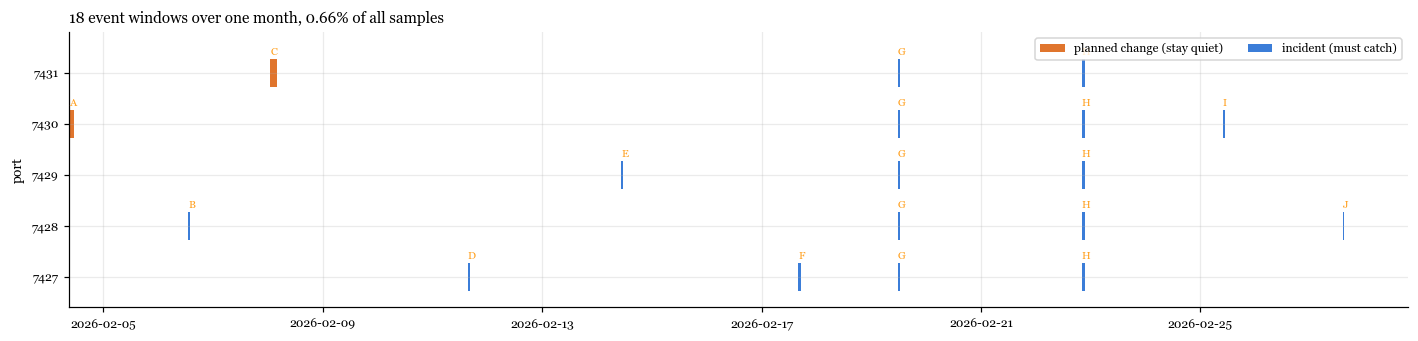

In [3]:
def shade(ax, time, mask, color=None, label="event"):
    """Shade every contiguous run of True in `mask`, collapsing them into one legend entry.

    Used on every time-series plot in both labs so the ground-truth windows are always
    marked the same way and can be compared across figures by eye.
    """
    v = np.asarray(pd.Series(mask).fillna(False), dtype=bool)
    idx = np.flatnonzero(v)
    if idx.size == 0:
        return
    brk = np.flatnonzero(np.diff(idx) > 1)          # a jump larger than 1 starts a new run
    starts, ends = np.r_[idx[0], idx[brk + 1]], np.r_[idx[brk], idx[-1]]
    t = pd.Series(time).reset_index(drop=True)
    for n, (a, b) in enumerate(zip(starts, ends)):
        ax.axvspan(t.iloc[a], t.iloc[b], color=color or C["truth"], alpha=0.3,
                   lw=0, zorder=0, label=label if n == 0 else None)


# Gantt view of the whole month. Blue and orange bars are the same shape in the raw
# traffic; only the calendar tells you which one should page somebody.
ports = sorted(raw["port_id"].unique())
fig, ax = plt.subplots(figsize=(13, 3.2))
for e in events.itertuples():
    ax.barh(ports.index(e.port_id), e.end - e.start, left=e.start, height=0.55,
            color=C["baseline"] if e.planned else C["signal"],
            label="planned change (stay quiet)" if e.planned else "incident (must catch)")
    ax.text(e.start, ports.index(e.port_id) + 0.35, e.event_id, fontsize=7, color=C["truth"])
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))                    # one legend entry per class, not per bar
ax.legend(uniq.values(), uniq.keys(), loc="upper right", ncol=2)
ax.set_yticks(range(len(ports)), [p[-4:] for p in ports])
ax.set_ylim(-0.6, len(ports) - 0.2)
ax.set(xlabel="", ylabel="port",
       title=f"{len(events)} event windows over one month, {BASE_RATE:.2%} of all samples")
fig.tight_layout(); plt.show()

### 小結

18 個 window 裡有 2 個是計畫性變更，也就是說**有 11% 的「異常」正確的處理方式是不要通知任何人**。這個比例不是偵測演算法能發現的，甘特圖上橘色與藍色的長條在原始流量裡形狀一樣。

這一步的貢獻是把召回率的分母定下來：16 個必須抓到，2 個必須安靜。少了 change calendar，後面每一個 recall 都會把「正確地保持安靜」記成漏抓。

檔案讀進來了，但還沒有任何一個數字被驗證過。下一步先確認這 43,200 列本身是不是可信的。

## 第 2 步：去重、排序與鍵值唯一性

在算任何統計之前，先確認兩件事：每一列代表的觀測是唯一的，而且時間是往前走的。

這兩件事在 poller 的輸出上經常不成立。SNMP 輪詢逾時會重送，補寫歷史會插入舊時間戳，兩個 collector 指到同一個 device 會讓每個區間出現兩列。這些都不會讓程式出錯，它們只會讓後面每一個 rolling 統計多算一次同一份證據。

這一步問三個問題：整列完全重複的有幾筆、`(port_id, timestamp)` 這組鍵重複的有幾筆、以及每個 port 的時間軸有沒有往回走。

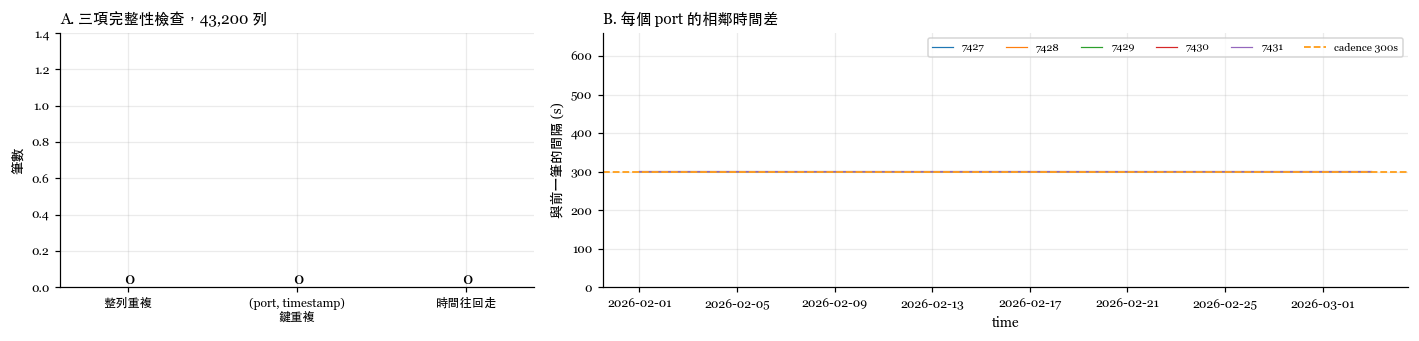

cadence 300s | 1h = 12 samples | 1d = 288 samples


In [4]:
raw = pd.read_csv(DATA / "synthetic_rrd_metrics.csv", parse_dates=["timestamp"])

# The identity of an observation is (port, timestamp), not the whole row. Two polls of the
# same port in the same interval can legitimately differ in value, so a full-row duplicate
# check would pass while the key is still doubled.
KEY = ["port_id", "timestamp"]
dup_rows = int(raw.duplicated().sum())
dup_keys = int(raw.duplicated(subset=KEY).sum())

# Backfilled history arrives with an old timestamp, so a negative gap is the signal.
# Measured per port, because the file interleaves ports and is not globally sorted.
raw = raw.sort_values(["device_id", "port_id", "timestamp"]).reset_index(drop=True)
gaps = raw.groupby("port_id")["timestamp"].diff().dt.total_seconds()
out_of_order = int((gaps < 0).sum())

CADENCE = float(gaps.median())
WINDOW = int(round(3600 / CADENCE))     # one hour, expressed in samples
DAY = int(round(86400 / CADENCE))       # one day, expressed in samples
ports = sorted(raw["port_id"].unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 3.2), gridspec_kw={"width_ratios": [1, 1.7]})

checks = {"整列重複": dup_rows, "(port, timestamp)\n鍵重複": dup_keys, "時間往回走": out_of_order}
axes[0].bar(range(len(checks)), list(checks.values()),
            color=[C["alert"] if v else C["peer"] for v in checks.values()], width=0.55)
for n, v in enumerate(checks.values()):
    axes[0].text(n, v, f" {v}", ha="center", va="bottom", fontsize=11)
axes[0].set_xticks(range(len(checks)), list(checks), fontsize=8)
axes[0].set(ylim=(0, max(max(checks.values()), 1) * 1.4), ylabel="筆數",
            title=f"A. 三項完整性檢查，{len(raw):,} 列")

# The gap trace carries both checks at once: a flat line at the cadence means no
# duplicates (gap 0), no backfill (gap < 0) and no missed polls (gap > cadence).
for pid in ports:
    g = raw[raw["port_id"] == pid]
    axes[1].plot(g["timestamp"].iloc[1:], g["timestamp"].diff().dt.total_seconds().iloc[1:],
                 lw=0.8, label=pid[-4:])
axes[1].axhline(CADENCE, color=C["truth"], ls="--", lw=1.2, label=f"cadence {CADENCE:.0f}s")
axes[1].set(ylim=(0, CADENCE * 2.2), ylabel="與前一筆的間隔 (s)", xlabel="time",
            title="B. 每個 port 的相鄰時間差")
axes[1].legend(ncol=6, fontsize=7, loc="upper right")
fig.tight_layout(); plt.show()

print(f"cadence {CADENCE:.0f}s | 1h = {WINDOW} samples | 1d = {DAY} samples")

### 探索練習：dedup 規則本身就是一個決定

三項檢查都是零，所以這份資料不需要任何修補。真實的 poller 輸出通常不是這樣，而重複出現的時候，「留哪一筆」沒有標準答案。

**任務**：造一份有重複的副本，比較三種 dedup 規則。

```python
dirty = pd.concat([raw, raw.sample(400, random_state=0)]).sort_values(["port_id", "timestamp"])
first = dirty.drop_duplicates(subset=KEY, keep="first")
last  = dirty.drop_duplicates(subset=KEY, keep="last")
avg   = dirty.groupby(KEY, as_index=False).mean(numeric_only=True)
```

觀察：

- 三種規則各留下幾列？跟原始的 43,200 差多少？
- 把 `INOCTETS` 畫出來，三條線分得出來嗎？

**討論**：`keep="first"` 假設先到的那筆才是真的，`keep="last"` 假設補寫是修正，取平均則假設兩筆都是同一個量的雜訊觀測。counter 型的欄位取平均會低估尖峰，因為重送的那一筆通常就是尖峰本身。這個選擇沒有寫在任何設定檔裡，但它決定了後面每一個 rolling 統計看到的東西。

## 第 3 步：缺值與時間軸完整性

上一步確認了現有的列沒有重複也沒有亂序。這一步問相反的問題：**該有的列都在嗎**。

差別是實質的。缺值有兩種形態，一種是列還在但欄位是 NaN（設備回了，但那個 OID 沒有值），另一種是整列不存在（設備沒回，poller 什麼都沒寫）。第二種在 dataframe 上完全看不見，`isna()` 數出來是零，因為那些列根本不在裡面。唯一找得到它的方法是拿實際列數去跟時間跨度算出來的名目列數比。

這一步同時把 cadence 釘死，因為後面每一個 window 長度都由它換算。

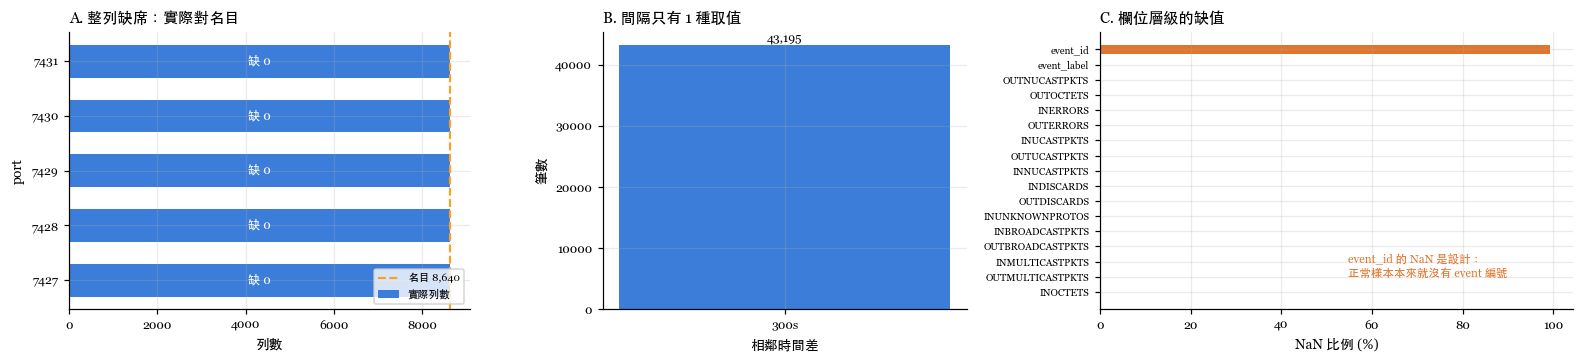

span 30.0 days | 每個 port 名目 8,640 列 | 實際最少 8,640 列
metric 欄位的 NaN 共 0 個，負值共 0 個


In [5]:
span = raw["timestamp"].max() - raw["timestamp"].min()
expected = int(round(span.total_seconds() / CADENCE)) + 1   # nominal rows per port over the span

coverage = (raw.groupby("port_id").size().rename("actual").to_frame()
            .assign(expected=expected)
            .assign(missing=lambda d: d["expected"] - d["actual"]))

# Two families of missing, counted separately because they are found in different ways.
METRIC_COLS = [c for c in raw.columns if c.isupper()]
na_share = raw[METRIC_COLS + ["event_id", "event_label"]].isna().mean().sort_values()

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.4),
                         gridspec_kw={"width_ratios": [1.1, 1, 1.3]})

y = np.arange(len(coverage))
axes[0].barh(y, coverage["actual"], color=C["signal"], height=0.6, label="實際列數")
axes[0].axvline(expected, color=C["truth"], ls="--", lw=1.4, label=f"名目 {expected:,}")
for n, t in enumerate(coverage.itertuples()):
    axes[0].text(t.actual * 0.5, n, f"缺 {t.missing}", va="center", ha="center",
                 fontsize=8, color="white")
axes[0].set_yticks(y, [p[-4:] for p in coverage.index], fontsize=8)
axes[0].set(xlabel="列數", ylabel="port", title="A. 整列缺席：實際對名目")
axes[0].legend(loc="lower right", fontsize=7)

# The gap histogram finds the same thing from the other direction. One bar means one cadence.
allgaps = raw.groupby("port_id")["timestamp"].diff().dt.total_seconds().dropna()
vals, counts = np.unique(allgaps, return_counts=True)
axes[1].bar([f"{v:.0f}s" for v in vals], counts, color=C["signal"], width=0.5)
for n, c in enumerate(counts):
    axes[1].text(n, c, f"{c:,}", ha="center", va="bottom", fontsize=8)
axes[1].set(ylabel="筆數", xlabel="相鄰時間差",
            title=f"B. 間隔只有 {len(vals)} 種取值")

axes[2].barh(range(len(na_share)), na_share.to_numpy() * 100,
             color=[C["muted"] if v == 0 else C["baseline"] for v in na_share], height=0.62)
axes[2].set_yticks(range(len(na_share)), na_share.index, fontsize=6.5)
axes[2].set(xlabel="NaN 比例 (%)", title="C. 欄位層級的缺值")
axes[2].text(na_share.max() * 100 * 0.55, 1.0,
             "event_id 的 NaN 是設計：\n正常樣本本來就沒有 event 編號",
             fontsize=7.5, color=C["baseline"])
fig.tight_layout(); plt.show()

print(f"span {span.total_seconds() / 86400:.1f} days | 每個 port 名目 {expected:,} 列 | "
      f"實際最少 {int(coverage['actual'].min()):,} 列")
print(f"metric 欄位的 NaN 共 {int(raw[METRIC_COLS].isna().sum().sum())} 個，"
      f"負值共 {int((raw[METRIC_COLS] < 0).sum().sum())} 個")

### 探索練習：三種補值各自扭曲了什麼

A 圖三根長條都頂到名目線，B 圖只有一種間隔，C 圖 metric 欄位全是零。這份資料的時間軸是完整的，所以後面每一個「12 筆的 window」真的就是一小時。有洞的資料不是這樣，補值方式會直接改變 window 裡的樣本數與離散程度。

**任務**：挖掉 2% 的樣本，比較三種處理。

```python
holed = raw.drop(raw.sample(frac=0.02, random_state=0).index)
grid = holed.set_index("timestamp").groupby("port_id").resample(f"{CADENCE:.0f}s").first()
ffill  = grid.ffill()
interp = grid.interpolate("time")
asis   = grid                     # 留著 NaN，讓 rolling 自己跳過
```

觀察：

- 三種處理的 `INOCTETS` 標準差各差多少？
- 用 `rolling(12).median()` 各算一次，補值那兩種的曲線在洞的位置是不是變平了？

**討論**：`ffill` 把最後一個已知值延續下去，在洞裡人工製造了一段零變異的資料，rolling scale 會因此縮小，第 4 步會看到縮小分母的後果。線性內插假設洞裡是平滑過渡，這對突發故障恰好是最壞的假設，因為故障就發生在洞裡的時候會被抹平成一條斜線。留著 NaN 最誠實，代價是每個 window 的有效樣本數不再固定，`min_periods` 這個參數從此有了實質作用。

## 第 4 步：雜訊處理：平滑要付的價錢

投影片上這一格的原則寫得很直接：**保留真實異常，避免大量噪音**。這兩個目標會打架，而平滑是最常見的處理方式，也是最常在沒有量過代價的情況下就套上去的。

滾動中位數濾波是最溫和的一種，它不會像移動平均那樣被單一極端值拉走。直覺上它只該拿掉毛刺。實際上它同時動到了後面 z-score 的分子與分母：

$$z = \frac{x - \text{center}}{\text{scale}}$$

平滑之後的 $x$ 離自己的 rolling center 更近，分子縮小；但 scale 是用同一批平滑過的值估出來的，分母也跟著縮小。**哪一邊縮得比較快，決定了平滑到底是幫忙還是幫倒忙**，而這件事逐欄不同，只能量。

下面在兩個代表性的欄位上量：一個 volume 型（每秒 bytes），一個 shape 型（broadcast 佔全部封包的比例）。這兩個名字第 6 步才正式定義，這裡先借用。

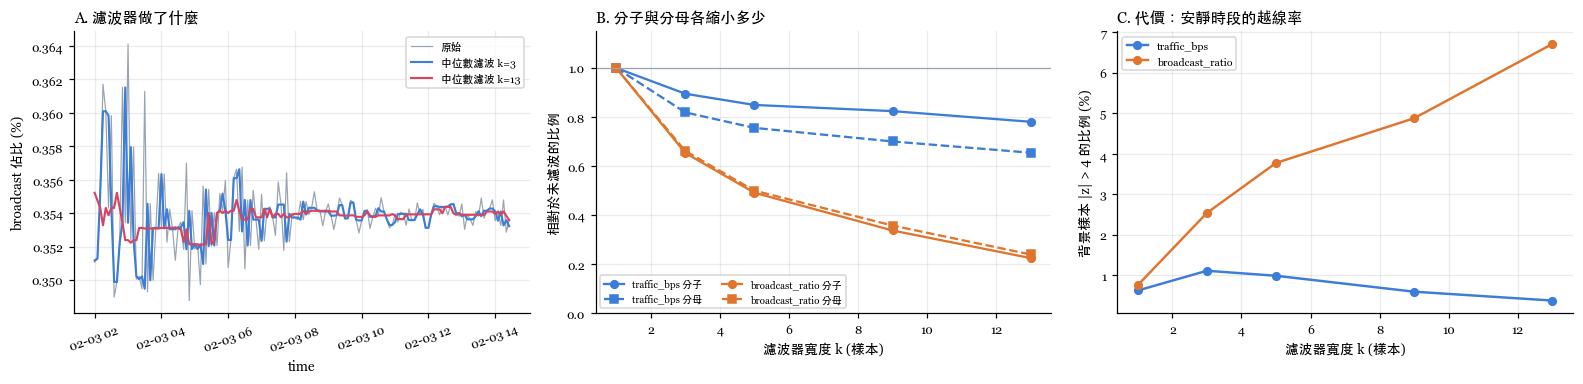

,col,k,num_ratio,den_ratio,background_breach
0,traffic_bps,1,1.00,1.00,0.0062
1,traffic_bps,3,0.89,0.82,0.0111
2,traffic_bps,5,0.85,0.76,0.0098
3,traffic_bps,9,0.82,0.70,0.0059
4,traffic_bps,13,0.78,0.65,0.0037
5,broadcast_ratio,1,1.00,1.00,0.0075
6,broadcast_ratio,3,0.65,0.66,0.0253
7,broadcast_ratio,5,0.49,0.50,0.0377
8,broadcast_ratio,9,0.34,0.36,0.0487
9,broadcast_ratio,13,0.23,0.24,0.0671


In [6]:
# The two feature families, previewed here because the filter behaves differently on each.
# Step 6 builds all thirteen; these two are literally the same expressions.
rate = raw[METRIC_COLS].astype(float) / CADENCE
probe = raw[["timestamp", "port_id", "event_label"]].copy()
probe["traffic_bps"] = rate["INOCTETS"] + rate["OUTOCTETS"]
all_pkts = (rate["INUCASTPKTS"] + rate["OUTUCASTPKTS"] + rate["INNUCASTPKTS"]
            + rate["OUTNUCASTPKTS"] + rate["INBROADCASTPKTS"] + rate["OUTBROADCASTPKTS"]
            + rate["INMULTICASTPKTS"] + rate["OUTMULTICASTPKTS"])
probe["broadcast_ratio"] = (rate["INBROADCASTPKTS"] + rate["OUTBROADCASTPKTS"]) / (all_pkts + 1e-9)
probe["is_event"] = probe["event_label"] != "normal"

KERNELS = [1, 3, 5, 9, 13]
PROBE_COLS = ["traffic_bps", "broadcast_ratio"]

rows = []
for col in PROBE_COLS:
    for k in KERNELS:
        num, den, breach = [], [], []
        for pid, g in probe.groupby("port_id", observed=True):
            g = g.sort_values("timestamp")
            # k = 1 leaves the series untouched, so it is the reference row rather than a special case.
            v = g[col] if k == 1 else g[col].rolling(k, center=True, min_periods=1).median()
            center, scale = rolling_robust(v, WINDOW)
            z = z_of(v, center, scale)
            num.append(float((v - center).abs().median()))
            den.append(float(scale.fillna(floor_of(v)).clip(lower=floor_of(v)).median()))
            breach.append(float((z.abs() > 4)[~g["is_event"].to_numpy()].mean()))
        rows.append({"col": col, "k": k, "numerator": np.mean(num), "denominator": np.mean(den),
                     "background_breach": np.mean(breach)})
smooth = pd.DataFrame(rows)
for col in PROBE_COLS:                                # express each as a ratio to the unfiltered row
    base = smooth[(smooth["col"] == col) & (smooth["k"] == 1)].iloc[0]
    m = smooth["col"] == col
    smooth.loc[m, "num_ratio"] = smooth.loc[m, "numerator"] / base["numerator"]
    smooth.loc[m, "den_ratio"] = smooth.loc[m, "denominator"] / base["denominator"]

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.6))

# A. what the filter does, on a stretch short enough to see individual samples.
seg = probe[probe["port_id"] == ports[0]].sort_values("timestamp").iloc[600:750]
axes[0].plot(seg["timestamp"], seg["broadcast_ratio"] * 100, color=C["muted"], lw=0.8,
             label="原始")
for k, colour in [(3, C["signal"]), (13, C["alert"])]:
    axes[0].plot(seg["timestamp"], seg["broadcast_ratio"].rolling(k, center=True,
                 min_periods=1).median() * 100, color=colour, lw=1.4, label=f"中位數濾波 k={k}")
axes[0].set(ylabel="broadcast 佔比 (%)", xlabel="time", title="A. 濾波器做了什麼")
axes[0].legend(fontsize=7)
axes[0].tick_params(axis="x", labelrotation=20)

# B. numerator and denominator on the same axis. Parallel lines mean z barely moves.
for col, colour in zip(PROBE_COLS, [C["signal"], C["baseline"]]):
    d = smooth[smooth["col"] == col]
    axes[1].plot(d["k"], d["num_ratio"], marker="o", ms=5, color=colour, lw=1.5,
                 label=f"{col} 分子")
    axes[1].plot(d["k"], d["den_ratio"], marker="s", ms=5, color=colour, lw=1.5, ls="--",
                 label=f"{col} 分母")
axes[1].axhline(1.0, color=C["muted"], lw=0.8)
axes[1].set(xlabel="濾波器寬度 k (樣本)", ylabel="相對於未濾波的比例", ylim=(0, 1.15),
            title="B. 分子與分母各縮小多少")
axes[1].legend(fontsize=6.5, ncol=2)

# C. the consequence, in the only unit that reaches the on-call engineer.
for col, colour in zip(PROBE_COLS, [C["signal"], C["baseline"]]):
    d = smooth[smooth["col"] == col]
    axes[2].plot(d["k"], d["background_breach"] * 100, marker="o", ms=5, color=colour,
                 lw=1.6, label=col)
axes[2].set(xlabel="濾波器寬度 k (樣本)", ylabel="背景樣本 |z| > 4 的比例 (%)",
            title="C. 代價：安靜時段的越線率")
axes[2].legend(fontsize=7)
fig.tight_layout(); plt.show()

display(smooth[["col", "k", "num_ratio", "den_ratio", "background_breach"]]
        .round({"num_ratio": 2, "den_ratio": 2, "background_breach": 4}))

圖上的越線率是一個比例，不太容易換算成值班的感受。把它跑成一個真正的偵測器，感受就直接了。

`rollout()` 從這裡開始出現，之後每一個方法都會經過它。它做三件事：分數超過門檻算一次越線，越線連續 `N_CONSEC` 筆才算一個 label，然後拿 label 去對 18 個標好的 event window 算成績。這個偵測器只用兩欄，很弱，但它已經是完整的一條路。

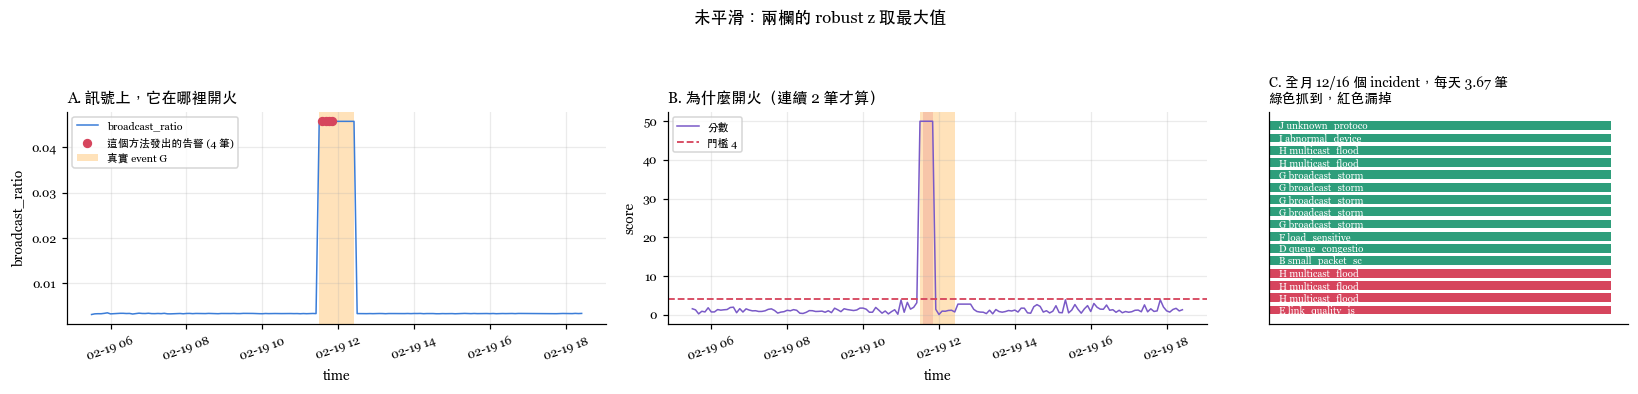

兩欄，未平滑                     threshold         4 | recall 12/16 |    3.67 labels/day | delay   5.0 min | event E ✗


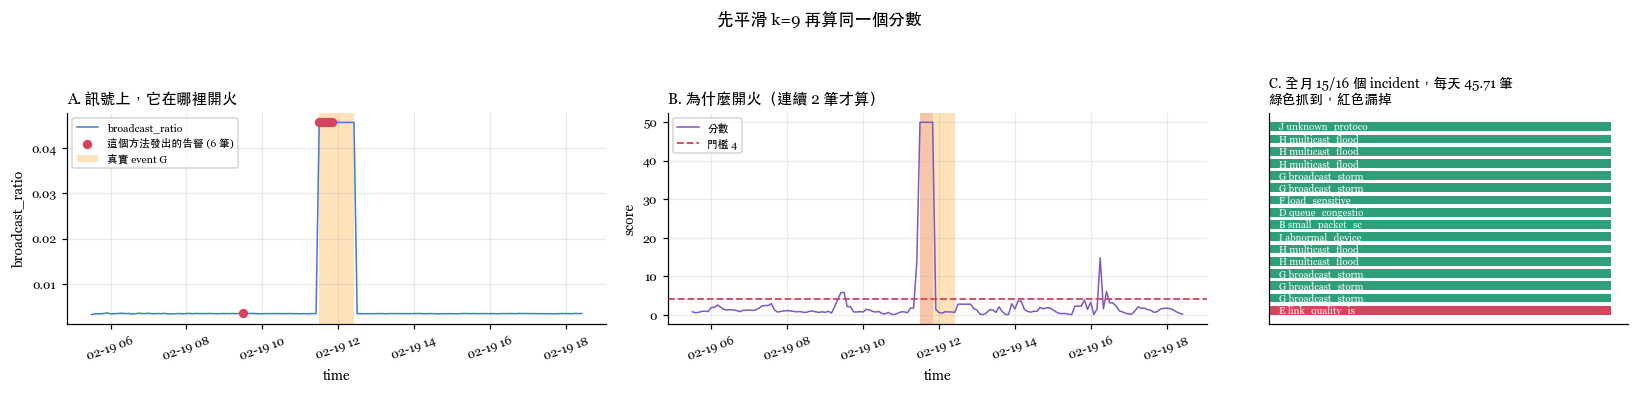

兩欄，中位數濾波 k=9               threshold         4 | recall 15/16 |   45.71 labels/day | delay   5.0 min | event E ✗


In [7]:
def two_column_score(frame, kernel=1):
    """Max |robust z| across the two probe columns, with an optional median filter first.

    kernel=1 leaves the series alone, so the same function produces both the filtered and
    the unfiltered detector and there is no second code path to keep in sync.
    """
    parts = []
    for pid, g in frame.groupby("port_id", observed=True):
        g = g.sort_values("timestamp")
        z = {}
        for col in PROBE_COLS:
            v = g[col] if kernel == 1 else g[col].rolling(kernel, center=True,
                                                          min_periods=1).median()
            z[col] = z_of(v, *rolling_robust(v, WINDOW)).abs()
        parts.append(pd.DataFrame(z, index=g.index))
    return pd.concat(parts).sort_index().max(axis=1)


det_raw = rollout("兩欄，未平滑", two_column_score(probe), probe, threshold=THRESHOLD)
det_smooth = rollout("兩欄，中位數濾波 k=9", two_column_score(probe, 9), probe, threshold=THRESHOLD)

plot_detection(det_raw, probe, event_id="G", col="broadcast_ratio",
               title="未平滑：兩欄的 robust z 取最大值")
plot_detection(det_smooth, probe, event_id="G", col="broadcast_ratio",
               title="先平滑 k=9 再算同一個分數")

兩張 A 格放在一起看，差別一眼就出來：橘色區塊外面的紅點變得又密又長。

C 格把它算成帳。平滑之後 recall 從 12 升到 15，確實多抓了三個 window，但每天的告警量從 3.67 筆跳到 45.71 筆，**多付了十二倍**。多抓三個 event 要不要用每天多四十筆去換，這是值班團隊的決定，不是預設值該替他們做的決定。

下一步用另一種方式減少雜訊，代價低很多。

### 探索練習：分開處理兩個 feature family

B 圖裡 `broadcast_ratio` 的兩條線幾乎重疊，分子與分母以相同比例縮小，所以 z 的中位數幾乎不動；C 圖卻顯示它的背景越線率隨 k 一路往上。動的是尾端而不是中央，這是只看平均值查不出來的那種退化。`traffic_bps` 的兩條線分開，分母縮得比分子快，行為又是另一回事。

同一個濾波器，兩個 feature family，兩種結果。這就是為什麼「先平滑再說」不是一個安全的預設。

**任務**：只平滑 volume，保留 ratio 原樣，或是換一種濾波器。

```python
v = g[col].rolling(k, center=True).mean()                    # 移動平均，會被極端值拉走
v = g[col].rolling(k, center=True).quantile(0.5)             # 等價於中位數
v = g[col].ewm(span=k).mean()                                # 指數加權，不需要置中
```

觀察：

- 移動平均的分母縮得比中位數濾波快還是慢？
- `center=True` 改成 `False` 之後，濾波器只看得到過去，尖峰的位置往哪邊移？

**討論**：`center=True` 用到了未來的樣本，這在離線分析可以，放到線上偵測就不行，因為那些樣本還沒發生。改成 `center=False` 之後，同樣的 k 會讓訊號延遲大約 k/2 筆，這個延遲要加到 Lab 02 第 15 步算出來的偵測延遲上。本課程後面的步驟一律不平滑，理由就在 C 圖：這份資料的雜訊沒有大到需要付這個價錢。

## 第 5 步：重採樣與時間窗聚合

平滑是在原本的取樣密度上抹掉高頻成分，聚合是直接換一個比較粗的時間軸。兩者的差別在於後者同時減少了資料量，而在真實部署裡，資料量就是保存成本與查詢延遲。

聚合的代價有一個乾淨的上界：**比 bucket 還短的 event，聚合完只剩某個 bucket 裡被平均掉的一小段，已經不成其為一個 event**。這份資料最短的 event 是 8 筆，也就是 40 分鐘，所以這個上界是可以直接算出來的，不必用猜的。

下面把同一份資料重採樣成四種 cadence，每一種都用同樣的 6 小時 baseline 視窗（掛鐘時間相同，樣本數不同），量三件事：抓到幾個 event、每天產生幾筆越線、以及資料剩幾列。

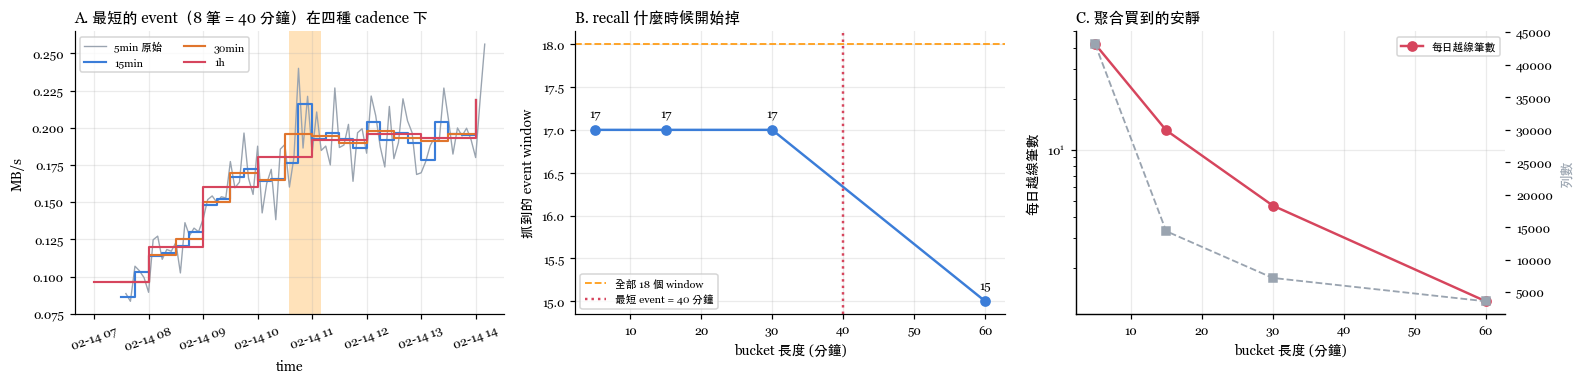

,rule,minutes,window_buckets,rows,caught,labels_per_day,shortest_event_buckets
0,5min,5,72,43200,17,42.004862,8.000000
1,15min,15,24,14400,17,13.004515,2.666667
2,30min,30,12,7200,17,4.669910,1.333333
3,1h,60,6,3600,15,1.268428,0.666667


In [8]:
RULES = [("5min", 5), ("15min", 15), ("30min", 30), ("1h", 60)]
WALL_HOURS = 6                       # baseline window fixed in wall-clock time across cadences

# Ground truth windows, rebuilt here because step 1 built them on the raw frame and the
# aggregated frames need the same (start, end) pairs to score against.
ev_windows = (raw[raw["event_label"] != "normal"]
              .groupby(["event_id", "port_id"], observed=True)
              .agg(start=("timestamp", "min"), end=("timestamp", "max"),
                   n=("timestamp", "size")).reset_index())

rows = []
for rule, mins in RULES:
    w = max(3, int(round(WALL_HOURS * 60 / mins)))
    parts = []
    for pid, g in probe.groupby("port_id", observed=True):
        g = g.set_index("timestamp").sort_index()
        agg = (g[PROBE_COLS] if mins * 60 == CADENCE
               else g[PROBE_COLS].resample(rule).mean()).reset_index()
        agg["port_id"] = pid
        for col in PROBE_COLS:
            agg["z_" + col] = z_of(agg[col], *rolling_robust(agg[col], w))
        parts.append(agg)
    rs = pd.concat(parts, ignore_index=True)

    score = rs[["z_" + c for c in PROBE_COLS]].abs().max(axis=1)
    breach = (score > 4).fillna(False)
    label = breach & breach.groupby(rs["port_id"]).shift(1).fillna(False)
    inside = pd.Series(False, index=rs.index)
    caught = 0
    for e in ev_windows.itertuples():
        m = (rs["port_id"] == e.port_id) & rs["timestamp"].between(e.start, e.end)
        inside |= m
        caught += bool(label[m].any())
    days = (rs["timestamp"].max() - rs["timestamp"].min()).total_seconds() / 86400
    if rule == "30min":
        agg30 = rs                       # kept for the rollout below
    rows.append({"rule": rule, "minutes": mins, "window_buckets": w, "rows": len(rs),
                 "caught": caught, "labels_per_day": float(label[~inside].sum() / days),
                 "shortest_event_buckets": float(ev_windows.n.min() * CADENCE / 60 / mins)})
resamp = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.6))

# A. the procedure itself, on the shortest event in the dataset.
short_ev = ev_windows.loc[ev_windows["n"].idxmin()]
pad = pd.Timedelta("3h")
w0 = probe[(probe["port_id"] == short_ev.port_id)
           & probe["timestamp"].between(short_ev.start - pad, short_ev.end + pad)]
axes[0].plot(w0["timestamp"], w0["traffic_bps"] / 1e6, color=C["muted"], lw=0.9, label="5min 原始")
for (rule, mins), colour in zip(RULES[1:], [C["signal"], C["baseline"], C["alert"]]):
    a = w0.set_index("timestamp")["traffic_bps"].resample(rule).mean()
    axes[0].step(a.index, a.to_numpy() / 1e6, where="post", lw=1.4, color=colour, label=rule)
axes[0].axvspan(short_ev.start, short_ev.end, color=C["truth"], alpha=0.3, lw=0)
axes[0].set(ylabel="MB/s", xlabel="time",
            title=f"A. 最短的 event（{int(short_ev.n)} 筆 = "
                  f"{int(short_ev.n * CADENCE / 60)} 分鐘）在四種 cadence 下")
axes[0].legend(fontsize=7, ncol=2)
axes[0].tick_params(axis="x", labelrotation=20)

axes[1].plot(resamp["minutes"], resamp["caught"], marker="o", ms=6, color=C["signal"], lw=1.6)
axes[1].axhline(len(ev_windows), color=C["truth"], ls="--", lw=1.2,
                label=f"全部 {len(ev_windows)} 個 window")
axes[1].axvline(ev_windows.n.min() * CADENCE / 60, color=C["alert"], ls=":", lw=1.6,
                label=f"最短 event = {int(ev_windows.n.min() * CADENCE / 60)} 分鐘")
for t in resamp.itertuples():
    axes[1].annotate(f"{t.caught}", (t.minutes, t.caught), textcoords="offset points",
                     xytext=(0, 8), ha="center", fontsize=8)
axes[1].set(xlabel="bucket 長度 (分鐘)", ylabel="抓到的 event window",
            title="B. recall 什麼時候開始掉")
axes[1].legend(fontsize=7, loc="lower left")

axes[2].plot(resamp["minutes"], resamp["labels_per_day"], marker="o", ms=6,
             color=C["alert"], lw=1.6, label="每日越線筆數")
axes[2].set(xlabel="bucket 長度 (分鐘)", ylabel="每日越線筆數", yscale="log",
            title="C. 聚合買到的安靜")
tw = axes[2].twinx(); tw.grid(False)
tw.plot(resamp["minutes"], resamp["rows"], marker="s", ms=5, color=C["muted"], lw=1.2, ls="--")
tw.set_ylabel("列數", color=C["muted"])
axes[2].legend(fontsize=7, loc="upper right")
fig.tight_layout(); plt.show()

display(resamp)

B 圖與 C 圖說的是同一件事的兩面，不過還是離「值班的人會收到什麼」有一段距離。把 30 分鐘那一版也跑成偵測器，跟上一步的兩個放在同一張 ledger 上比。

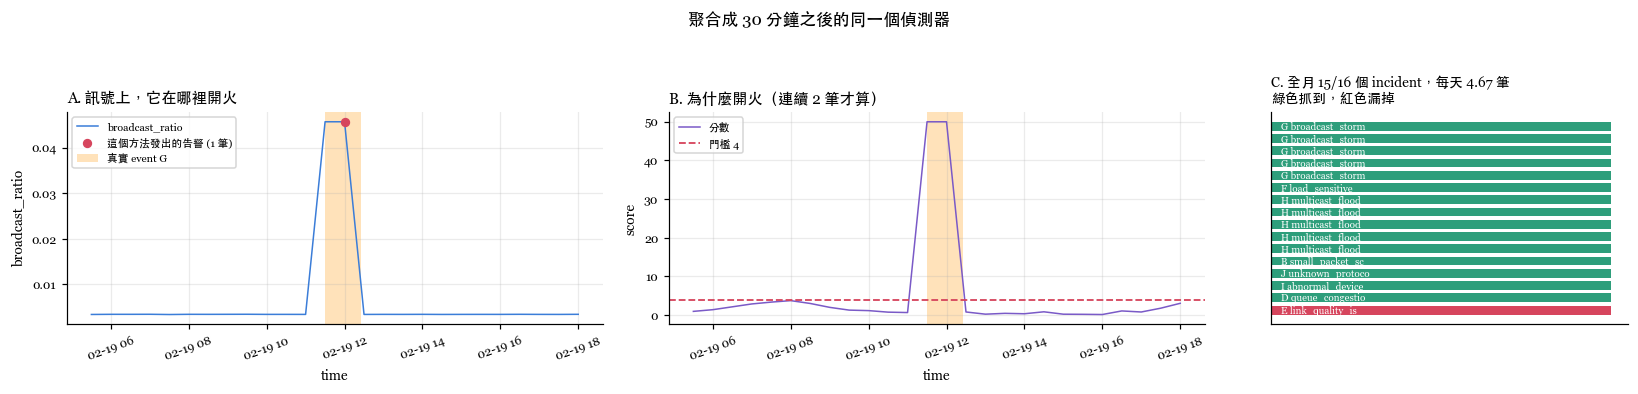

兩欄，聚合成 30 分鐘               threshold         4 | recall 15/16 |    4.67 labels/day | delay  25.0 min | event E ✗


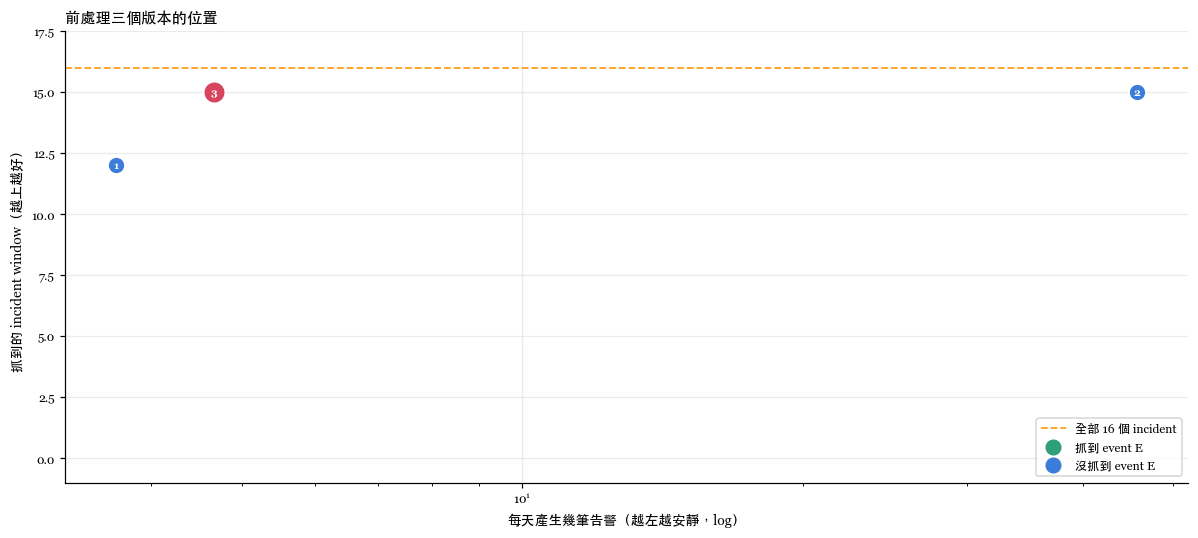

,方法,抓到,每日筆數,延遲(分),抓到E
1,兩欄，未平滑,12,3.67,5.0,False
2,兩欄，中位數濾波 k=9,15,45.71,5.0,False
3,兩欄，聚合成 30 分鐘,15,4.67,25.0,False


,name,threshold,recall,of,labels_per_day,median_delay_min,caught_E
1,兩欄，未平滑,4.0,12,16,3.67,5.0,False
2,兩欄，中位數濾波 k=9,4.0,15,16,45.71,5.0,False
3,兩欄，聚合成 30 分鐘,4.0,15,16,4.67,25.0,False


In [9]:
det_agg = rollout("兩欄，聚合成 30 分鐘", agg30[["z_" + c for c in PROBE_COLS]].abs().max(axis=1),
                  agg30, threshold=THRESHOLD)
plot_detection(det_agg, agg30, event_id="G", col="broadcast_ratio",
               title="聚合成 30 分鐘之後的同一個偵測器")

# Everything rolled out so far, on one plane. A method has to move up or left to be worth
# keeping; landing on top of an earlier point means it added nothing.
plot_ledger(highlight="兩欄，聚合成 30 分鐘", title="前處理三個版本的位置")

ledger 上三個點的位置說完了整件事。聚合與平滑都停在 15/16，但聚合每天只要 4.67 筆，平滑要 45.71 筆，**同樣的抓取能力，價差十倍**。

聚合也不是免費的。C 格的延遲從 5 分鐘變成 25 分鐘，因為一個 30 分鐘的 bucket 要等它收滿。安靜是用時間換來的。

這張 ledger 之後每加一個方法就會多一個點，Lab 02 結束時上面會有十幾個。判讀方式固定：往左是更安靜，往上是抓得更多，落在別人正上方或正右方就是沒有貢獻。

### 探索練習：換一個聚合函數

B 圖的 recall 一路持平到 30 分鐘的 bucket，C 圖的每日越線筆數同時從 42.0 降到 4.7，資料量剩六分之一。這段區間裡聚合幾乎是免費的。掉下去的位置由最短 event 決定，不是由取樣率決定，紅色虛線標的就是那條界線：最短的 event 有 40 分鐘，換成 1 小時的 bucket 之後它連一格都填不滿。

`mean` 只是眾多選擇之一，而它對短而尖的 event 最不利，因為 bucket 裡大部分是正常值。

**任務**：把聚合函數換掉，重新執行這一格。

```python
agg = g[PROBE_COLS].resample(rule).max()                     # 保留尖峰
agg = g[PROBE_COLS].resample(rule).quantile(0.95)            # 保留尖峰但不被單點主導
agg = g[PROBE_COLS].resample(rule).agg(["mean", "max"])      # 兩個都留，欄位變兩倍
```

觀察：

- 換成 `max` 之後，1 小時 bucket 的 recall 回來了嗎？
- 背景的每日越線筆數漲了幾倍？

**討論**：`max` 保留尖峰，代價是背景的雜訊尖峰也一起保留，所以它同時提高 recall 與誤報。ratio 型的欄位還有一個額外的陷阱：先聚合再算比例，和先算比例再聚合，結果不一樣，因為比例的平均不等於平均的比例。低流量的 bucket 在第一種做法裡權重被壓低，這通常才是想要的，Lab 02 第 16 步的 minimum volume gate 處理的是同一個問題。

本課程後面一律留在 5 分鐘的原始 cadence，因為這份資料只有 43,200 列，聚合省下來的成本還不值得付出那 2 個 window。資料量再大兩個數量級的時候，這張圖就是決定 bucket 長度的依據。


## 第 6 步：counter 轉成兩類 feature

除以 cadence 得到每秒速率，再組成兩類變數。**volume** 表達「量」，**shape** 表達「型態」。

下面把原始欄位與工程後的訊號並排。左邊是直接從 CSV 讀出來的兩欄，右邊是偵測器實際會計分的變熟。兩邊的形狀相近，因為 feature engineering 沒有改變發生過什麼，只轉換特徵；真正被改變的是可比較性，而左圖標註的 IN share 說明了為什麼單看一欄不夠。


In [10]:
RAW_COLS = ["INOCTETS", "OUTOCTETS", "INUCASTPKTS", "OUTUCASTPKTS", "INNUCASTPKTS",
            "OUTNUCASTPKTS", "INBROADCASTPKTS", "OUTBROADCASTPKTS", "INMULTICASTPKTS",
            "OUTMULTICASTPKTS", "INERRORS", "OUTERRORS", "INDISCARDS", "OUTDISCARDS",
            "INUNKNOWNPROTOS"]

tel = raw[["timestamp", "device_id", "port_id", "port_role", "event_label", "event_id"]].copy()

# Each raw row already holds the total accumulated within one polling interval, so the
# per-second rate is just the value divided by the cadence. This is the only unit
# conversion in the lab; no differencing is involved.
r = raw[RAW_COLS].astype(float) / CADENCE

eps = 1e-9                                           # guards every ratio denominator
rx, tx = r["INOCTETS"], r["OUTOCTETS"]
ucast = r["INUCASTPKTS"] + r["OUTUCASTPKTS"]         # one-to-one traffic
nucast = r["INNUCASTPKTS"] + r["OUTNUCASTPKTS"]      # legacy MIB: broadcast + multicast combined
bcast = r["INBROADCASTPKTS"] + r["OUTBROADCASTPKTS"]
mcast = r["INMULTICASTPKTS"] + r["OUTMULTICASTPKTS"]
errors = r["INERRORS"] + r["OUTERRORS"]              # transmission failures, hardware or cabling
discards = r["INDISCARDS"] + r["OUTDISCARDS"]        # delivered but dropped, congestion or QoS
packets = ucast + nucast
all_pkts = packets + bcast + mcast

# Volume family: how much is flowing. Direction is merged because a fault rarely
# respects it, and keeping both directions doubles the columns without adding evidence.
tel["traffic_bps"] = rx + tx
tel["packets_pps"] = packets
tel["errors_pps"] = errors
tel["discards_pps"] = discards
tel["unknown_proto_pps"] = r["INUNKNOWNPROTOS"]

# Shape family: what kind of traffic it is. Every one of these is a ratio, so it is
# already scale free and comparable across ports of very different sizes.
tel["avg_pkt_bytes"] = (rx + tx) / (all_pkts + eps)          # large = bulk transfer, small = scan
tel["broadcast_ratio"] = bcast / (all_pkts + eps)            # ARP storm, switching loop
tel["multicast_ratio"] = mcast / (all_pkts + eps)            # IGMP problems, flooding
tel["nonucast_ratio"] = (bcast + mcast) / (all_pkts + eps)   # the two floods as one signal
tel["tx_ratio"] = tx / (rx + tx + eps)                       # direction balance, 0.5 = symmetric
tel["error_rate"] = errors / (packets + eps)
tel["discard_rate"] = discards / (packets + eps)
tel["err_disc_rate"] = (errors + discards) / (packets + eps)  # link quality as one number

VOLUME = ["traffic_bps", "packets_pps", "errors_pps", "discards_pps", "unknown_proto_pps"]
SHAPE = ["avg_pkt_bytes", "broadcast_ratio", "multicast_ratio", "nonucast_ratio",
         "tx_ratio", "error_rate", "discard_rate", "err_disc_rate"]
FEATURES = VOLUME + SHAPE

tel["is_event"] = tel["event_label"] != "normal"     # per-sample ground truth, used by every plot
display(tel[["timestamp", "port_id"] + FEATURES].head(3))

,timestamp,port_id,traffic_bps,packets_pps,errors_pps,discards_pps,unknown_proto_pps,avg_pkt_bytes,broadcast_ratio,multicast_ratio,nonucast_ratio,tx_ratio,error_rate,discard_rate,err_disc_rate
0,2026-02-01 00:00:00,port-id7429,21525.205133,18.490000,0.0,0.0,0.0,1155.198844,0.002683,0.005009,0.007692,0.649177,0.0,0.0,0.0
1,2026-02-01 00:05:00,port-id7429,18405.044233,19.143333,0.0,0.0,0.0,954.123599,0.002765,0.004838,0.007603,0.636731,0.0,0.0,0.0
2,2026-02-01 00:10:00,port-id7429,20414.775567,19.636667,0.0,0.0,0.0,1031.744048,0.002695,0.004885,0.007581,0.603459,0.0,0.0,0.0


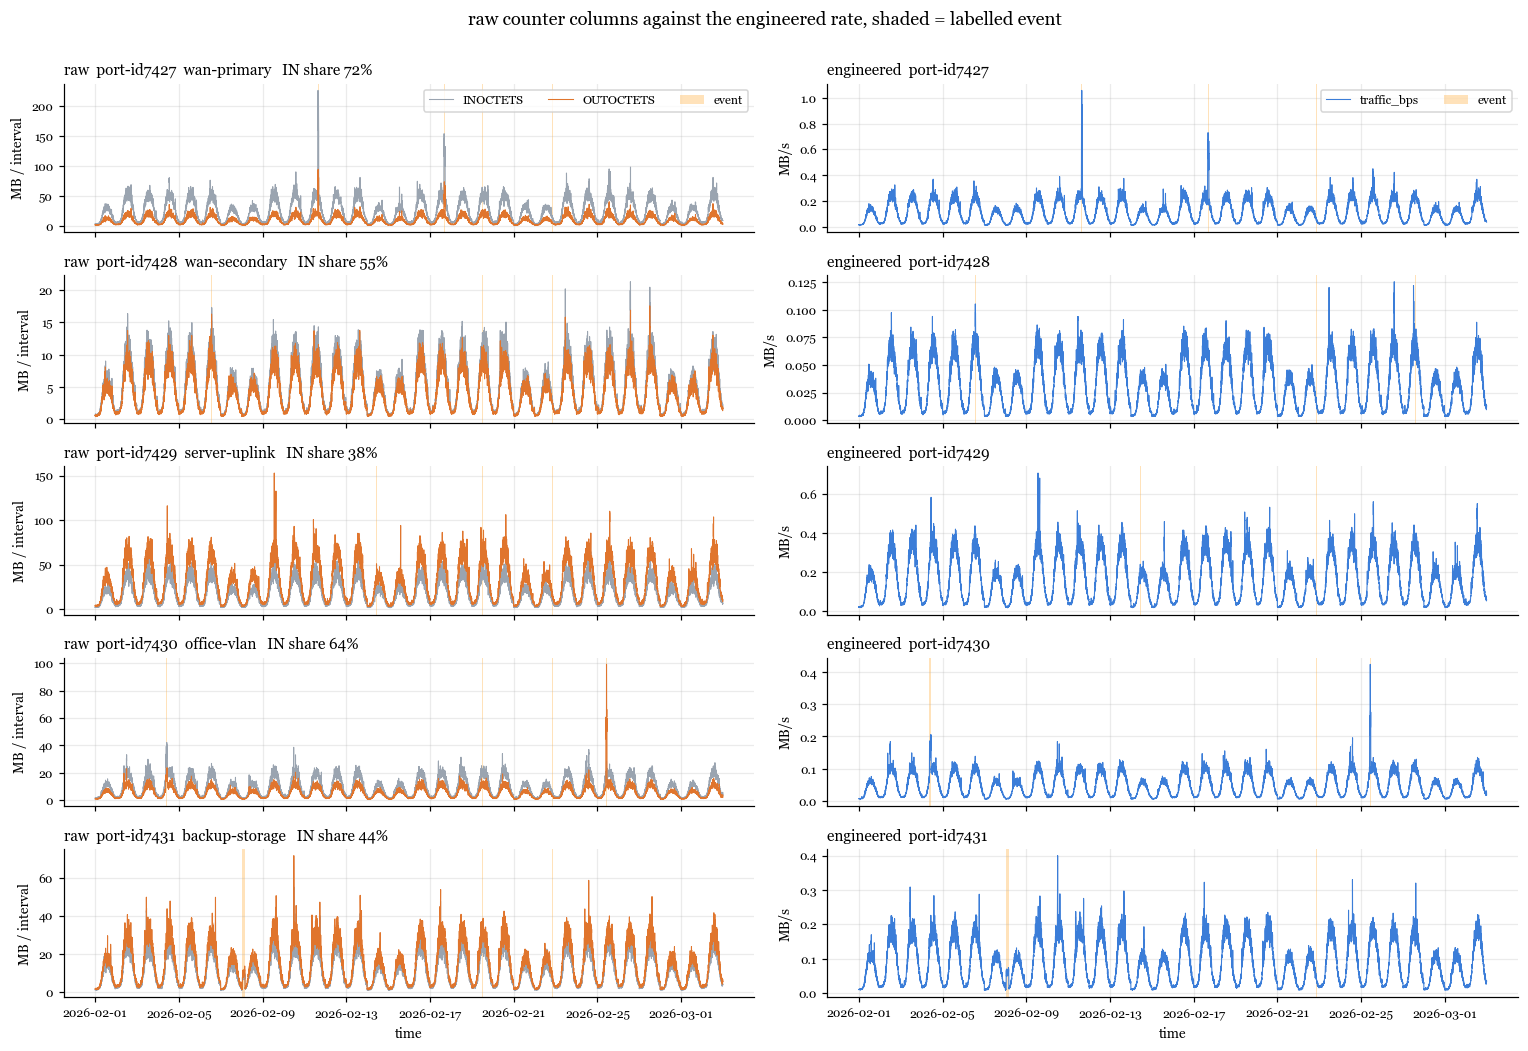

In [11]:
# Raw against engineered, one row per port. Left is a single column read straight out of
# the CSV; right is what the detector will actually score. The shapes rhyme, which is the
# point: engineering did not change what happened, only what is measurable. What it did
# change is comparability, and the IN share printed on each left panel says why one raw
# column is not the signal. On a port that sends more than it receives, INOCTETS alone
# tracks the smaller half of the traffic.
fig, axes = plt.subplots(len(ports), 2, figsize=(14, 1.9 * len(ports)), sharex=True)
for (left, right), p in zip(axes, ports):
    r_one = raw[raw["port_id"] == p]
    e_one = tel[tel["port_id"] == p]
    role = e_one["port_role"].iloc[0]
    in_share = r_one["INOCTETS"].sum() / (r_one["INOCTETS"].sum() + r_one["OUTOCTETS"].sum())

    left.plot(r_one["timestamp"], r_one["INOCTETS"] / 1e6, color=C["muted"], lw=0.7,
              label="INOCTETS")
    left.plot(r_one["timestamp"], r_one["OUTOCTETS"] / 1e6, color=C["baseline"], lw=0.7,
              label="OUTOCTETS")
    left.set(ylabel="MB / interval",
             title=f"raw  {p}  {role}   IN share {in_share:.0%}")

    right.plot(e_one["timestamp"], e_one["traffic_bps"] / 1e6, color=C["signal"], lw=0.7,
               label="traffic_bps")
    right.set(ylabel="MB/s", title=f"engineered  {p}")

    for ax in (left, right):
        shade(ax, e_one["timestamp"], e_one["is_event"])
axes[0, 0].legend(loc="upper right", ncol=3)
axes[0, 1].legend(loc="upper right", ncol=2)
for ax in axes[-1]:
    ax.set_xlabel("time")
fig.suptitle("raw counter columns against the engineered rate, shaded = labelled event",
             y=1.001)
fig.tight_layout(); plt.show()

### 小結

左右兩欄的形狀幾乎一樣，這正是要看到的：feature engineering 沒有創造訊號。真正改變的是 IN share 標出來的那件事，五個 port 從 38% 到 72%，所以「哪一欄代表流量」在不同 port 上是不同的答案，而 `traffic_bps` 讓它變成同一個答案。

這一步的貢獻是把 15 個原始欄位變成 13 個可比較的量，並且把它們分成 volume 與 shape 兩類。第 12 步會量出這兩類之間的相關性只有 0.33，也就是它們真的在回答不同的問題。

### 探索練習：換一個欄位看同一個月

**任務**：把繪圖那一格的 `traffic_bps` 換成 `broadcast_ratio`，再換成 `avg_pkt_bytes`。

```python
ax.plot(one["timestamp"], one["broadcast_ratio"], color=C["signal"], lw=0.7)
```

觀察：

- 同一批陰影時段，三次浮出水面的是不是同一批 event？
- 哪一個欄位讓最多 event 用肉眼就看得出來？

**討論**：ratio 的分母是選出來的。`error_rate` 用 `packets`，`broadcast_ratio` 用 `all_pkts`，換一個分母就換了一個問題。IN 與 OUT 在這裡被合併掉了，`tx_ratio` 是唯一還看得到方向的欄位。

## 第 7 步：scale profile

五個 port 的流量規模跨越數倍，橫跨三個實體設備。任何「流量大於 X Mbps 就 alert」的規則，對至少一部分 port 必然是錯的。

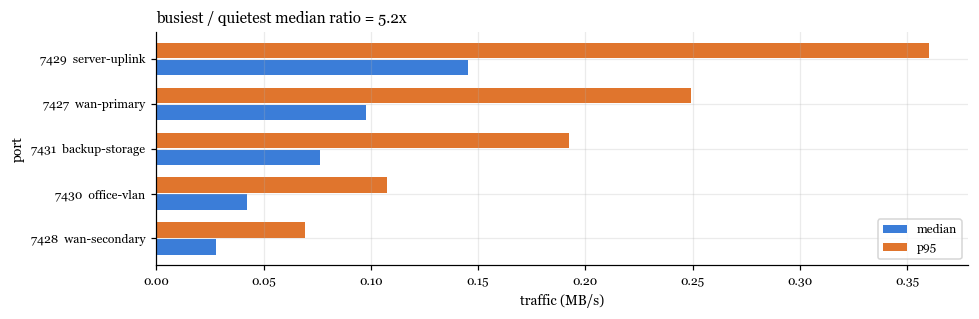

In [12]:
# Median and p95 per port. Median says where the port normally sits, p95 says how far
# its ordinary busy periods reach, and the gap between them differs by port too.
scale = (tel.groupby(["device_id", "port_id", "port_role"], observed=True)["traffic_bps"]
         .agg(median="median", p95=lambda s: s.quantile(0.95)).reset_index()
         .sort_values("median"))
scale[["median", "p95"]] /= 1e6                      # bytes/s to MB/s, easier to read on the axis

y = np.arange(len(scale))
fig, ax = plt.subplots(figsize=(9, 3.0))
ax.barh(y - 0.19, scale["median"], height=0.34, color=C["signal"], label="median")
ax.barh(y + 0.19, scale["p95"], height=0.34, color=C["baseline"], label="p95")
ax.set_yticks(y, [f"{t.port_id[-4:]}  {t.port_role}" for t in scale.itertuples()])
ax.set(xlabel="traffic (MB/s)", ylabel="port",
       title=f"busiest / quietest median ratio = {scale['median'].max() / scale['median'].min():.1f}x")
ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

### 小結

流量中位數差 5.2 倍，這是預期中的。**沒有預期到的是 p95 除以 median 這個比值在五個 port 上是 2.48 到 2.55，幾乎完全一樣。**

這個對比很有用：port 之間差的是水位，不是相對的離散程度。所以逐 port 減掉自己的 center 再除以自己的 scale 就夠了，不需要為不同 port 設計不同的分數形狀。如果那五個比值也散開，$(x - \text{center}) / \text{scale}$ 這個殼本身就不夠用了。

### 探索練習：scale 差異與離散程度是兩件事

**任務**：把長條圖改成畫 `p95 / median` 的比值。

```python
scale["ratio"] = scale["p95"] / scale["median"]
```

觀察：

- 流量最大的 port，離散程度也最大嗎？
- 兩張圖的排序一樣嗎？

**討論**：normalization 只解決 scale 差異，不解決離散程度差異。p95 這個分位數也是任意選的，改成 p99 會把偶發尖峰算進「正常的忙碌」。

## 第 8 步：zero-value profile：哪些欄位撐不起 z-score

$(x - \text{center}) / \text{scale}$ 需要有意義的離散度。當一欄大半時間貼在零，rolling scale 會塌到下限，任何非零讀數都會被一個接近零的數字除，產生巨大而無意義的 score。

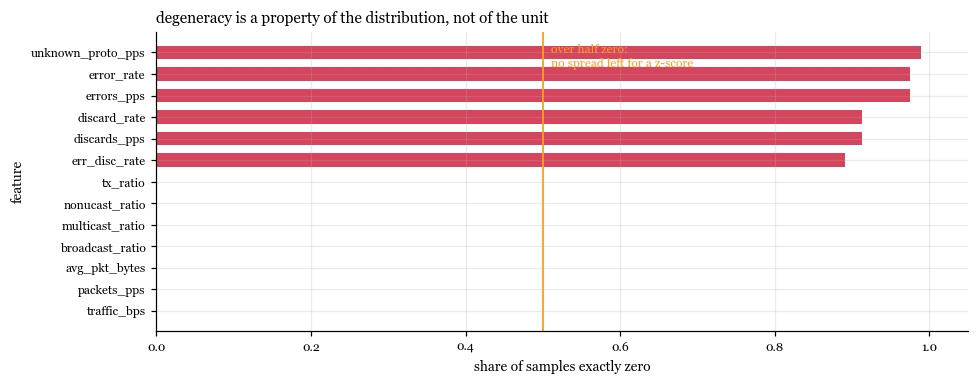

scorable  : ['traffic_bps', 'packets_pps', 'avg_pkt_bytes', 'broadcast_ratio', 'multicast_ratio', 'nonucast_ratio', 'tx_ratio']
degenerate: ['err_disc_rate', 'discards_pps', 'discard_rate', 'errors_pps', 'error_rate', 'unknown_proto_pps']


In [13]:
# The practical test for whether a z-score means anything on a column: once too many
# samples sit at exactly zero, there is no spread left for the denominator to estimate.
zero_frac = (tel[FEATURES] == 0).mean().sort_values()
DEGENERATE = zero_frac[zero_frac > 0.5].index.tolist()
SCORABLE = [f for f in FEATURES if f not in DEGENERATE]

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(range(len(zero_frac)), zero_frac.to_numpy(),
        color=[C["alert"] if v > 0.5 else C["signal"] for v in zero_frac], height=0.62)
ax.axvline(0.5, color=C["truth"], lw=1.2)
ax.text(0.51, len(zero_frac) - 0.6, "over half zero:\nno spread left for a z-score",
        fontsize=8, color=C["truth"], va="top")
ax.set_yticks(range(len(zero_frac)), zero_frac.index, fontsize=8)
ax.set(xlim=(0, 1.05), xlabel="share of samples exactly zero", ylabel="feature",
       title="degeneracy is a property of the distribution, not of the unit")
fig.tight_layout(); plt.show()

print("scorable  :", SCORABLE)
print("degenerate:", DEGENERATE)

### 小結

這張圖最重要的訊息是**中間沒有東西**。七個 scorable 欄位的零值比例是 0.000，六個 degenerate 欄位是 0.89 到 0.99，中間完全空白。

所以 0.5 這條界線在這份資料上根本不敏感，從 0.01 到 0.85 都會切出同一組名單。這一步的貢獻在於證明這兩類欄位在分佈上是分離的，各自聚在一端，中間沒有過渡帶。找到一個好的閾值反而是次要的。真實資料不見得這麼乾淨，界線落在灰色地帶時，就要換第 11 步那個更貼近失效機制的判斷標準：量 rolling scale 貼到下限的比例。

### 探索練習：0.5 這條界線是你設的

**任務**：把 degenerate 的判斷標準改成 0.3，再改成 0.8。

```python
DEGENERATE = zero_frac[zero_frac > 0.3].index.tolist()
```

觀察：

- `SCORABLE` 的名單各差幾欄？
- 第 14 步的 ablation 結論會跟著變嗎？

**討論**：這裡用「剛好等於零的比例」當判斷標準，另一個標準是量 rolling scale 貼到下限的比例，那個更貼近失效的機制，但要先算完 baseline 才知道。先算便宜的，還是先算準的？另外，這個標準套在全體資料上，某個 port 有離散度而其他四個沒有，現在會被一起判成 degenerate。

## 第 9 步：distribution：z-score 在這一欄可信嗎

直方圖疊一條同 mean 同 standard deviation 的 normal reference curve。兩者的差距，就是 z-score 在這一欄可以被信任的程度。

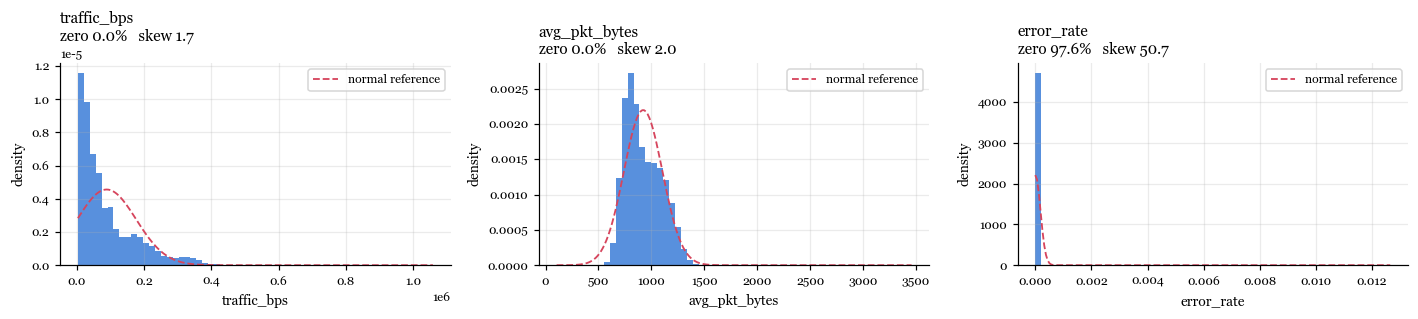

In [14]:
# Overlaying a matched normal curve turns "is a z-score meaningful here" into something
# you can see. A good fit means the sigma axis is trustworthy; a spike at zero means
# this column needs a fixed threshold instead.
show = ["traffic_bps", "avg_pkt_bytes", "error_rate"]
fig, axes = plt.subplots(1, len(show), figsize=(13, 3.0))
for ax, col in zip(axes, show):
    v = tel[col].dropna()
    ax.hist(v, bins=60, density=True, color=C["signal"], alpha=0.85)
    mu, sd = v.mean(), v.std()
    grid = np.linspace(v.min(), v.max(), 200)
    ax.plot(grid, np.exp(-0.5 * ((grid - mu) / sd) ** 2) / (sd * np.sqrt(2 * np.pi)),
            color=C["alert"], ls="--", lw=1.2, label="normal reference")
    ax.legend()
    ax.set(xlabel=col, ylabel="density",
           title=f"{col}\nzero {(v == 0).mean():.1%}   skew {v.skew():.1f}")
fig.tight_layout(); plt.show()

### 小結

偏度把三欄分成兩個世界：`traffic_bps` 是 1.7、`avg_pkt_bytes` 是 2.0、`error_rate` 是 50.7。前兩者是右偏但仍有形狀的分佈，後者的偏度來自 97.6% 的樣本剛好等於零。

所以「4 個 sigma 以外很罕見」這句話在前兩欄上是誇張，在第三欄上是無意義。這一步的貢獻是告訴你不能拿常態表反推閾值，Lab 02 第 5 步會把這個差距量成一個倍數。

### 探索練習：換一個 scale 再看一次分佈

**任務**：把直方圖的資料改成取對數。

```python
v = np.log1p(tel[col].dropna())
```

觀察：

- normal reference curve 貼合得多好？
- 零附近那根尖峰消失了嗎？

**討論**：貼合了就代表在對數 scale 上計分比較合理。normal reference curve 是最粗的檢查，QQ plot 對尾端更敏感；在 43,200 筆上任何常態檢定都會拒絕，所以圖比 p-value 有用。

## 第 10 步：autocorrelation：rolling window 長度的下限

一個代表「正常」的 rolling window，長度必須跨越至少一個最強週期，否則它會把正常的日節律當成偏離，每天固定產生一次 false alarm。

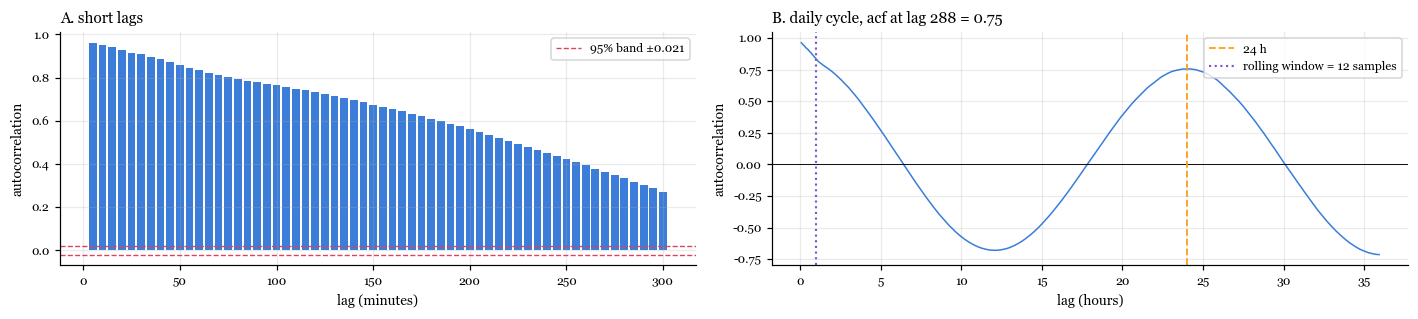

In [15]:
# Autocorrelation says how long this series keeps resembling its own past. Anything
# above the white-noise band is real structure that a rolling window has to respect.
s = tel[tel["port_id"] == ports[0]]["traffic_bps"].reset_index(drop=True)
lags = np.arange(1, 3 * DAY // 2)
acf = np.array([s.autocorr(lag=int(k)) for k in lags])
conf = 1.96 / np.sqrt(len(s))                        # 95% band under the white-noise null

fig, axes = plt.subplots(1, 2, figsize=(13, 3.0))
short = lags <= 60                                   # panel A zooms into the first few hours
axes[0].bar(lags[short] * CADENCE / 60, acf[short], width=CADENCE / 60 * 0.8,
            color=[C["signal"] if abs(v) > conf else C["muted"] for v in acf[short]])
axes[0].axhline(conf, color=C["alert"], ls="--", lw=0.9, label=f"95% band ±{conf:.3f}")
axes[0].axhline(-conf, color=C["alert"], ls="--", lw=0.9)
axes[0].set(xlabel="lag (minutes)", ylabel="autocorrelation", title="A. short lags")
axes[0].legend()

axes[1].plot(lags * CADENCE / 3600, acf, color=C["signal"], lw=1.0)
axes[1].axhline(0, color="black", lw=0.6)
axes[1].axvline(24, color=C["truth"], ls="--", lw=1.2, label="24 h")
axes[1].axvline(WINDOW * CADENCE / 3600, color=C["score"], ls=":", lw=1.4,
                label=f"rolling window = {WINDOW} samples")
axes[1].set(xlabel="lag (hours)", ylabel="autocorrelation",
            title=f"B. daily cycle, acf at lag {DAY} = {acf[DAY - 1]:.2f}")
axes[1].legend()
fig.tight_layout(); plt.show()

### 小結

lag 1 的自相關是 0.962。**相鄰兩筆樣本有 96% 的共同資訊，所以 12 筆的 window 裡並沒有 12 份獨立證據。** 一天之後（lag 288）還有 0.754，日週期是真的。

這一步的貢獻是給出兩個下游後果。一是 window 長度的下限：1 小時的 window 短於日週期，會把早晨的爬升讀成偏離。二是 Lab 02 第 5 步的前提：越線會成群出現，任何假設樣本獨立的誤報估計都會低估。

而第 11 步用的仍然是 12 筆，也就是明知故犯。代價是每天固定一次的季節性誤判，換來的是對突發事件的反應速度。真正的解法不是調長度，是 Lab 02 第 2 步換一種比較對象。

### 探索練習：把 window 拉長到一整天

**任務**：把第 11 步的 `WINDOW` 從 12 改成 288，重新執行第 11 步。

```python
WINDOW = 288   # 一整天，而不是一小時
```

觀察：

- 日節律造成的偏離消失了嗎？
- 比 window 還長的 event（例如 event C，36 筆）還看得見嗎？

**討論**：兩難的出口不是調長度，是換一種比較對象，也就是 Lab 02 第 2 步的 seasonal baseline。這一格只畫了 `ports[0]`，五個 port 的日週期強度不一樣，office-vlan 的節律遠比 backup-storage 明顯。

## 第 11 步：rolling baseline 與 robust z

同一個殼 $(x - \text{center}) / \text{scale}$，換兩種估計法：

| | center | scale | 對 window 內的 outlier |
|---|---|---|---|
| `rolling mean` | mean | standard deviation | 第一個 outlier 就被拉走 |
| `rolling robust` | median | MAD × 1.4826 | 污染過半之前不動 |

scale 再加一個下限，避免安靜時段的分母塌到零。這四個函式在最上面的設定格已經定義過，因為第 4 步與第 5 步就需要 scale 的估計，這一步要看的是兩種估計法之間的差別。


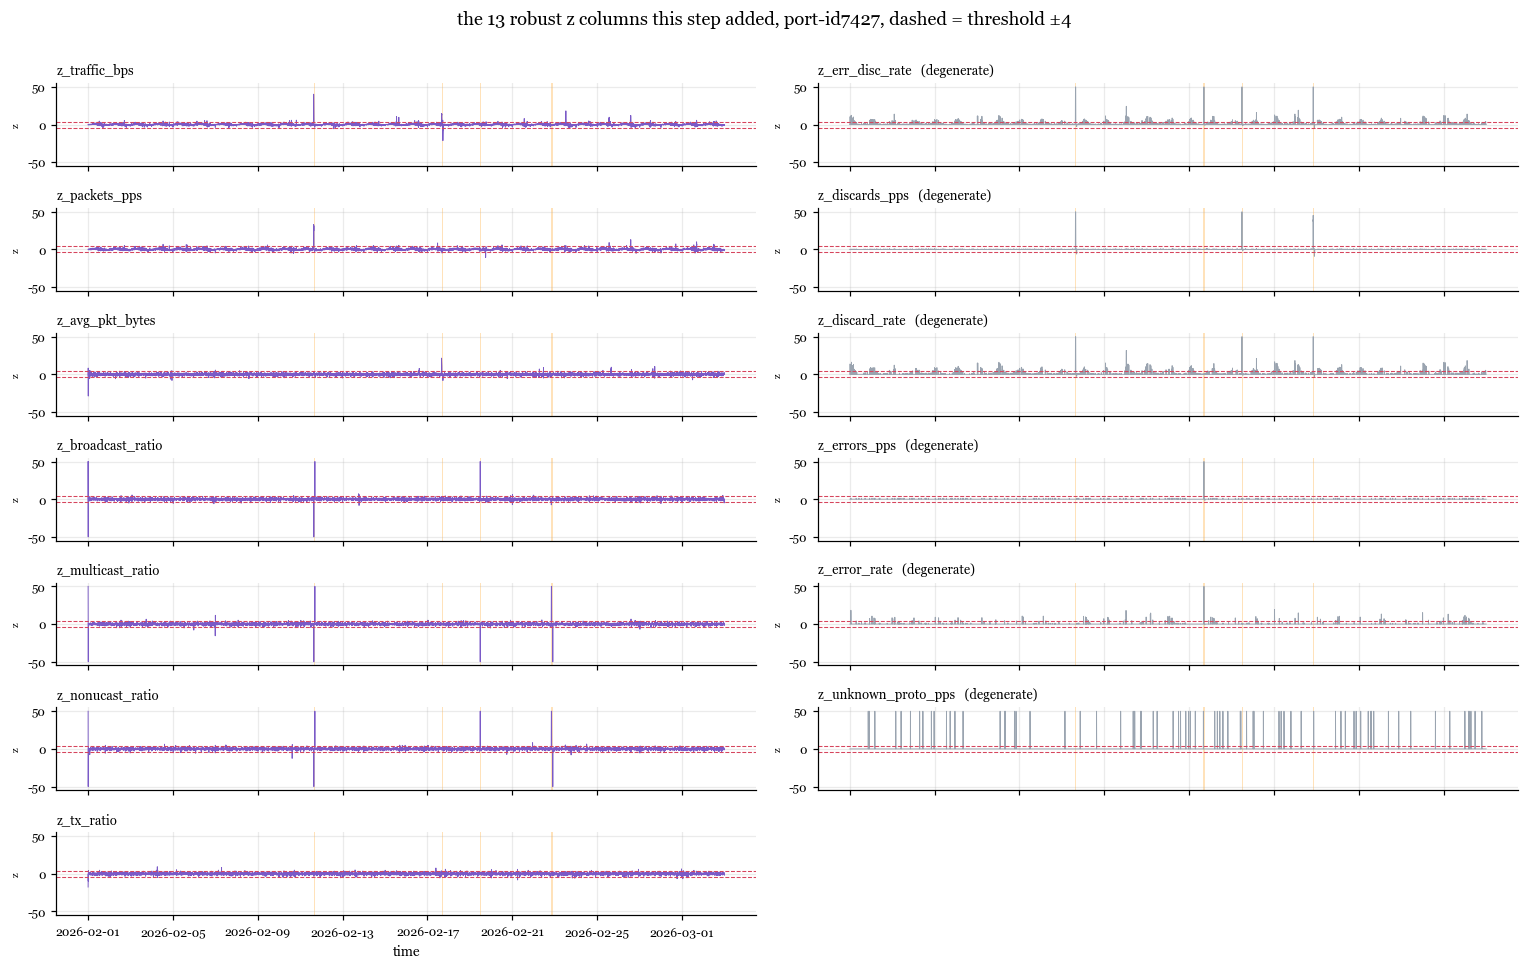

13 robust z columns added (7 scorable, 6 degenerate)


In [16]:
# The four helpers this cell uses (floor_of, rolling_mean, rolling_robust,
# z_of) are defined once in the setup cell, because steps 4 and 5 already
# needed the scale estimate. What is new here is the comparison between the
# two estimator pairs, which is what the table above is about.
# Every baseline is computed per port. Mixing ports would let a busy port's numbers
# define what counts as normal for a quiet one, which is the failure step 7 illustrated.
# Drop anything a previous run of this cell produced. Without this, re-running it
# concatenates a second copy of every generated column onto the frame, and the next
# cell silently reads a duplicated column instead of the one it names.
tel = tel.drop(columns=[c for c in tel.columns if c.startswith("z_") or "__" in c],
               errors="ignore")

parts = []
for pid, g in tel.groupby("port_id", observed=True):
    g = g.sort_values("timestamp").copy()
    new = {}
    for col in FEATURES:
        v = g[col].astype(float)
        m, sd = rolling_mean(v, WINDOW)
        med, mad = rolling_robust(v, WINDOW)
        new[f"{col}__mean"] = m                      # kept for the comparison plot below
        new[f"{col}__std"] = sd
        new[f"{col}__center"] = med
        new[f"{col}__scale"] = mad
        new[f"z_{col}"] = z_of(v, med, mad)          # the robust score Lab 02 starts from
    # Build the new columns in one frame and concat once, rather than inserting them
    # one at a time into a 43k-row frame.
    parts.append(pd.concat([g, pd.DataFrame(new, index=g.index)], axis=1))
tel = pd.concat(parts).sort_index()

# Every column this cell just added, on one port, so you can see what was created rather
# than take the count on trust. Purple panels are the columns step 8 called scorable, grey
# panels the degenerate ones. Compare how often each side crosses the dashed threshold on
# ordinary days: the grey side reaches the cap on samples that are nothing but background,
# which is what dividing by a floored scale produces.
LOOK = "port-id7427"
one = tel[tel["port_id"] == LOOK].sort_values("timestamp")
rows = -(-len(FEATURES) // 2)
fig, axes = plt.subplots(rows, 2, figsize=(14, 1.25 * rows), sharex=True)
for ax, col in zip(axes.T.flat, SCORABLE + DEGENERATE):
    degenerate = col in DEGENERATE
    ax.plot(one["timestamp"], one[f"z_{col}"],
            color=C["muted"] if degenerate else C["score"], lw=0.6)
    for level in (4, -4):
        ax.axhline(level, color=C["alert"], ls="--", lw=0.7)
    shade(ax, one["timestamp"], one["is_event"])
    ax.set_ylim(-MAX_SCORE * 1.1, MAX_SCORE * 1.1)
    ax.set_ylabel("z", fontsize=7)
    ax.set_title(f"z_{col}" + ("   (degenerate)" if degenerate else ""), fontsize=8.5)
for ax in axes.T.flat[len(FEATURES):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("time")
fig.suptitle(f"the {len(FEATURES)} robust z columns this step added, {LOOK}, "
             f"dashed = threshold ±4", y=1.002)
fig.tight_layout(); plt.show()

print(f"{len([c for c in tel.columns if c.startswith('z_')])} robust z columns added "
      f"({len(SCORABLE)} scorable, {len(DEGENERATE)} degenerate)")

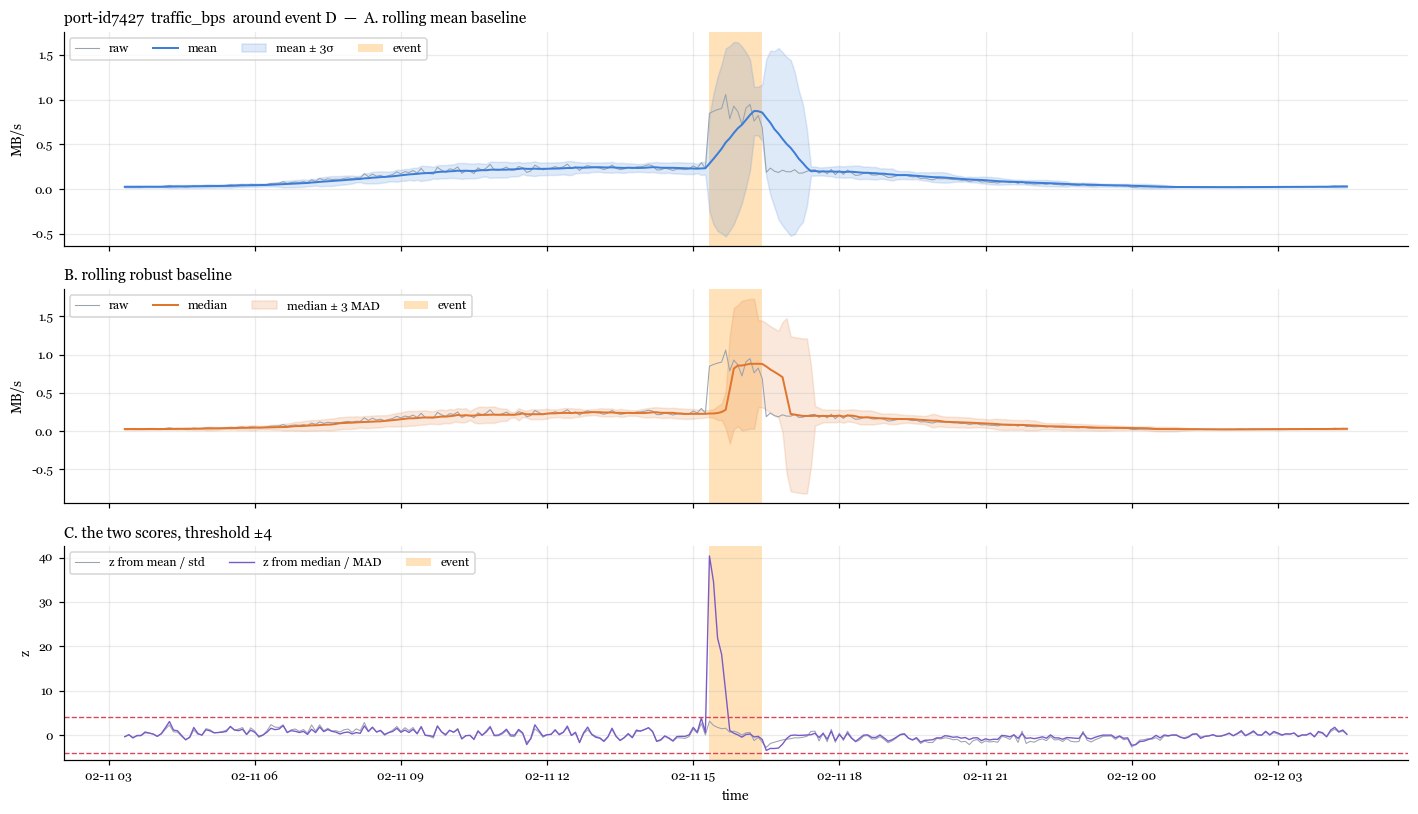

In [17]:
# Same port, same feature, three views: the two baselines drawn as expected ranges, then
# the two scores they produce on one axis so the difference is directly comparable.
# A whole month at this cadence is 8,640 points per port and the two lines would sit on
# top of each other, so zoom to one event with a day of context on either side.
COL = "traffic_bps"
ev = events[events.event_id == "D"].iloc[0]
p = tel[(tel["port_id"] == ev.port_id)
        & tel["timestamp"].between(ev.start - pd.Timedelta("12h"), ev.end + pd.Timedelta("12h"))
        ].sort_values("timestamp")
PORT = ev.port_id

fig, axes = plt.subplots(3, 1, figsize=(13, 7.5), sharex=True)
axes[0].plot(p["timestamp"], p[COL] / 1e6, color=C["muted"], lw=0.7, label="raw")
axes[0].plot(p["timestamp"], p[f"{COL}__mean"] / 1e6, color=C["signal"], lw=1.3, label="mean")
axes[0].fill_between(p["timestamp"], (p[f"{COL}__mean"] - 3 * p[f"{COL}__std"]) / 1e6,
                     (p[f"{COL}__mean"] + 3 * p[f"{COL}__std"]) / 1e6,
                     color=C["signal"], alpha=0.16, label="mean ± 3σ")
axes[0].set(ylabel="MB/s", title=f"{PORT}  {COL}  around event D  —  A. rolling mean baseline")

axes[1].plot(p["timestamp"], p[COL] / 1e6, color=C["muted"], lw=0.7, label="raw")
axes[1].plot(p["timestamp"], p[f"{COL}__center"] / 1e6, color=C["baseline"], lw=1.3, label="median")
axes[1].fill_between(p["timestamp"], (p[f"{COL}__center"] - 3 * p[f"{COL}__scale"]) / 1e6,
                     (p[f"{COL}__center"] + 3 * p[f"{COL}__scale"]) / 1e6,
                     color=C["baseline"], alpha=0.16, label="median ± 3 MAD")
axes[1].set(ylabel="MB/s", title="B. rolling robust baseline")

axes[2].plot(p["timestamp"], z_of(p[COL], p[f"{COL}__mean"], p[f"{COL}__std"]),
             color=C["muted"], lw=0.7, label="z from mean / std")
axes[2].plot(p["timestamp"], p[f"z_{COL}"], color=C["score"], lw=0.9, label="z from median / MAD")
for level in (4, -4):
    axes[2].axhline(level, color=C["alert"], ls="--", lw=0.9)
axes[2].set(ylabel="z", xlabel="time", title="C. the two scores, threshold ±4")

for ax in axes:
    shade(ax, p["timestamp"], p["is_event"])
    ax.legend(loc="upper left", ncol=4)
fig.tight_layout(); plt.show()

到這裡為止，13 欄的 robust z 全部算完了。這是本節第一個像樣的偵測器，所以值得完整執行一次，看看它到底抓到什麼。

分數的合成方式是跨欄取最大值，任何一欄夠極端就算數。為什麼是 max 而不是平均，第 12 步的相關矩陣會給出理由。

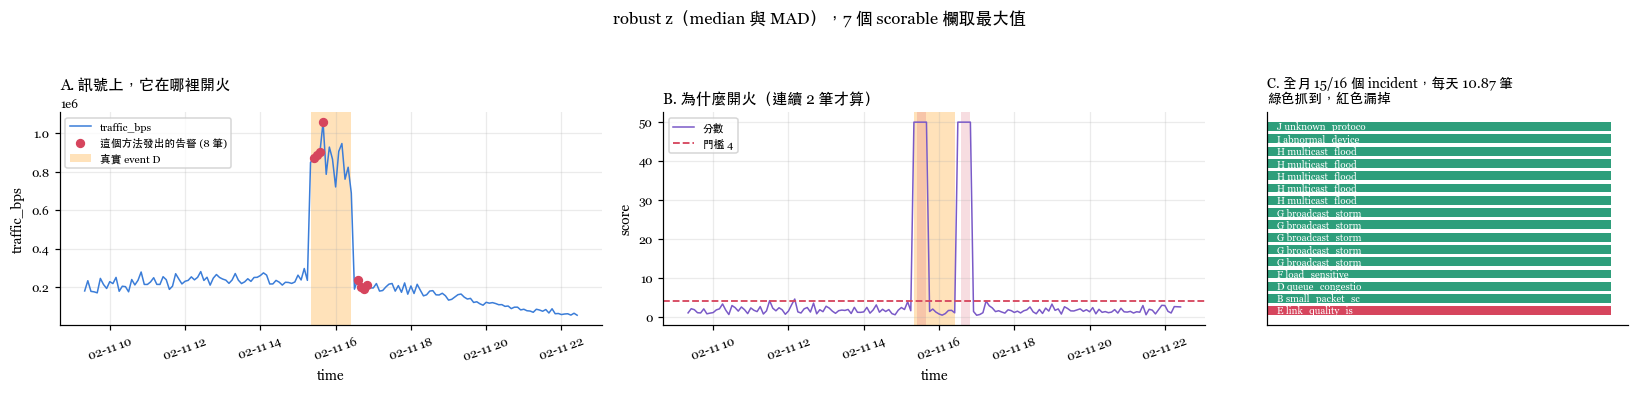

robust z，7 欄               threshold         4 | recall 15/16 |   10.87 labels/day | delay   5.0 min | event E ✗


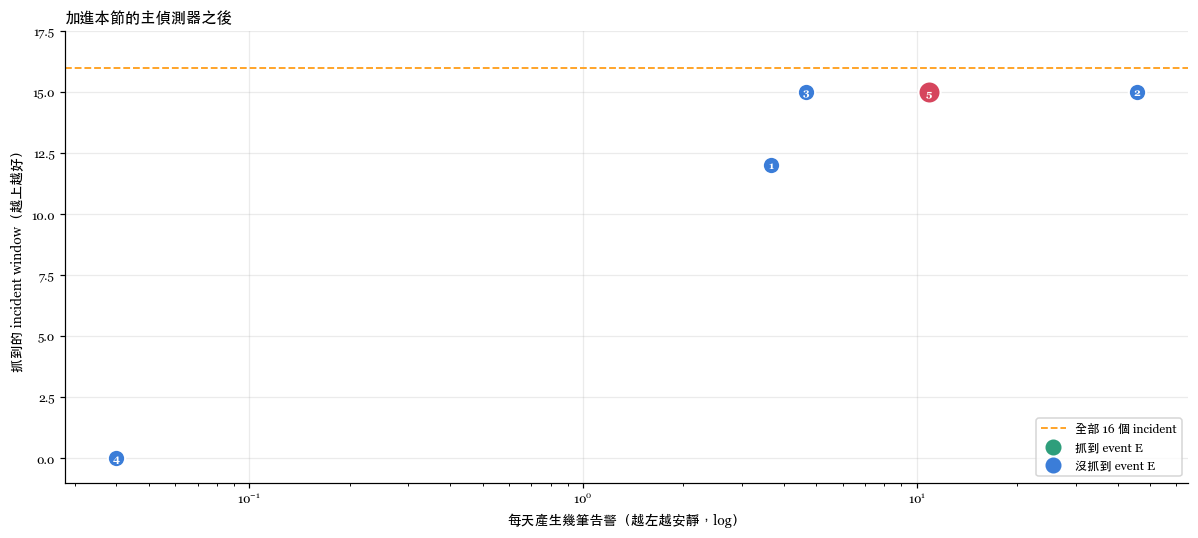

,方法,抓到,每日筆數,延遲(分),抓到E
1,兩欄，未平滑,12,3.67,5.0,False
2,兩欄，中位數濾波 k=9,15,45.71,5.0,False
3,兩欄，聚合成 30 分鐘,15,4.67,25.0,False
4,rolling mean z，7 欄,0,0.00,NaN,False
5,robust z，7 欄,15,10.87,5.0,False


,name,threshold,recall,of,labels_per_day,median_delay_min,caught_E
1,兩欄，未平滑,4.0,12,16,3.67,5.0,False
2,兩欄，中位數濾波 k=9,4.0,15,16,45.71,5.0,False
3,兩欄，聚合成 30 分鐘,4.0,15,16,4.67,25.0,False
4,rolling mean z，7 欄,4.0,0,16,0.00,NaN,False
5,robust z，7 欄,4.0,15,16,10.87,5.0,False


In [18]:
# The two estimator pairs, each rolled out the same way, so the difference in the scorecard
# is attributable to the estimator and to nothing else.
z_robust_max = tel[[f"z_{c}" for c in SCORABLE]].abs().max(axis=1)
z_mean_max = pd.concat(
    [z_of(tel[c], tel[f"{c}__mean"], tel[f"{c}__std"]).abs() for c in SCORABLE],
    axis=1).max(axis=1)

det_mean = rollout("rolling mean z，7 欄", z_mean_max, tel, threshold=THRESHOLD)
det_robust = rollout("robust z，7 欄", z_robust_max, tel, threshold=THRESHOLD)

plot_detection(det_robust, tel, event_id="D", col="traffic_bps",
               title="robust z（median 與 MAD），7 個 scorable 欄取最大值")
plot_ledger(highlight="robust z，7 欄", title="加進本節的主偵測器之後")

A 格的紅點集中在橘色區塊上，區塊外面零星幾顆，這是一個可用的偵測器該有的樣子。C 格給出全月 15/16。

上面兩行成績單的差距大得不像同一個公式：**robust 版 15/16，mean 版 0/16，一個都沒抓到。** 機制在第 7 步那張圖裡已經畫出來了。event 一進來就把自己算進 rolling mean 的 window，center 被拖上去、std 同時撐開，分子縮小分母變大，分數還沒來得及越線就被自己的 baseline 追平。median 與 MAD 要污染過半才會動，這個月的 event 大多短於半個 window，所以它撐得住。

同一個殼、同一個門檻、同一批欄位，只換了 center 與 scale 的估計法，成績從滿分掉到零。Lab 02 第 4 步會把這個崩潰過程一格一格量出來。

接下來四步不再新增方法，改問這 13 欄裡哪幾欄真的在出力。

### 小結

小圖陣列右半邊那六欄就是 degenerate 欄位的實際行為，而它跟直覺相反。**在原始單位上這些欄位幾乎不動**（大半時間是零），**但它們的 z 劇烈擺盪**：raw 的變異係數是 13.7 到 59.9，scorable 那邊只有 0.20 到 0.98。

機制在分母。scale 塌到下限之後，z 量的幾乎只剩「這一筆是不是非零」，離正常多遠這件事已經量不到了。後果可以直接數出來：`errors_pps` 在**沒有事件**的樣本上有 1.43% 直接頂到 ±50 的上限，`unknown_proto_pps` 是 0.79%。scorable 那邊 `traffic_bps`、`packets_pps`、`avg_pkt_bytes`、`tx_ratio` 在背景樣本上一次都沒有碰到上限，三個 ratio 欄位碰到的比例是 0.05% 到 0.11%，比 degenerate 那邊低一個數量級。

所以你的判讀是對的，而且可以講得更準：degenerate 欄位給出的峰值不帶資訊，不是因為它們沒反應，是因為它們對純背景與對真實故障的反應分不開。`errors_pps` 背景越線 1.43%、事件內越線 3.85%，只差 2.7 倍。`traffic_bps` 是 0.62% 對 8.04%，差 13 倍。同一個門檻，同一個公式，分離度差了五倍。

### 探索練習：window 長度的影響

**任務**：把 `WINDOW` 從 `12`（1 小時）改成 `6`（30 分鐘），重新執行這兩格。

```python
WINDOW = 6
```

觀察：

- rolling mean 的曲線是不是更抖？
- expected range 是不是變窄了？
- 已知 event 時段更明顯，還是冒出更多 false alarm？

**討論**：window 越短偵測越敏感，false alarm 也越多，你的環境偏向哪一側？這一格還有三個寫死的常數：`min_periods = w // 3`、floor 的 `fraction = 0.05`、`MAX_SCORE = 50`。mean/std 與 median/MAD 只是 center 與 scale 的兩種估計法，IQR、trimmed mean、Huber 都能插進同一個殼。

## 第 12 步：feature correlation：哪兩欄是同一份證據

用 Spearman rank correlation，因為這種 telemetry 偏態嚴重，Pearson 會被少數極端值主導。

兩個高度相關的 feature 分開計分，只是把同一份證據數了兩次，false alarm 加倍而偵測力沒有增加。這也是後面跨 feature 取最大值而不是加總的理由。

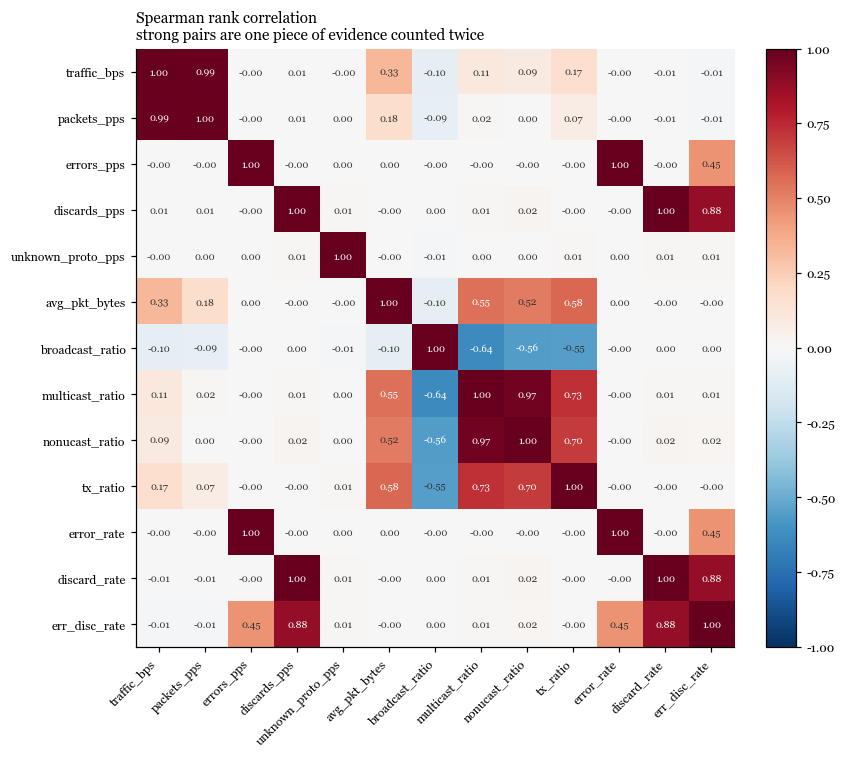

In [19]:
# Rank correlation, not linear correlation: ranks are unaffected by the heavy right tail
# that every traffic column has, so the number reflects co-movement rather than outliers.
corr = tel[FEATURES].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.4, 7.0))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(FEATURES)), FEATURES, fontsize=8)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        v = corr.iat[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if abs(v) > 0.55 else "#333333")
ax.grid(False)
ax.set_title("Spearman rank correlation\nstrong pairs are one piece of evidence counted twice")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout(); plt.show()

### 小結

有三對的 Spearman 相關到達 0.97 以上：`errors_pps` 與 `error_rate` 是 1.00，`discards_pps` 與 `discard_rate` 是 1.00，`traffic_bps` 與 `packets_pps` 是 0.99。前兩對是同一個量除以一個幾乎不變的分母，等於同一份證據被數了兩次。

另一半的結果同樣重要：volume 兩欄對 shape 四欄的最大相關只有 0.33。**兩類 feature 真的在回答不同的問題**，這是第 6 步那個分類的實證，也是 Lab 02 用 max 而不是 sum 合成分數的理由。相關的欄位取 max 不會重複計票，取 sum 會。

### 探索練習：換一種相關係數

**任務**：把 `method="spearman"` 改成 `"pearson"`。

```python
corr = tel[FEATURES].corr(method="pearson")
```

觀察：

- 哪幾格變化最大？
- 變化大的那幾欄，零值比例或偏態是不是也特別高？

**討論**：變化大的那幾欄就是被極端值主導的那幾欄。這張圖是把五個 port 混在一起算的，某兩欄在 wan-primary 上高度相關、在 backup-storage 上不相關，這裡看不出來。

## 第 13 步：event × feature heatmap：每個 feature 的盲點

每一格是該 event window 內、該 feature 的帶號峰值 z。**接近白色代表這一欄看不見這個 event。**

event B（`small_packet_scan`）是最乾淨的例子：封包數上升、平均封包大小同步崩落，而 `traffic_bps` 是兩者的乘積，兩個變化互相抵消。用某個量換取另一個量、乘積大致不變的故障，對測量該乘積的 feature 不可見。

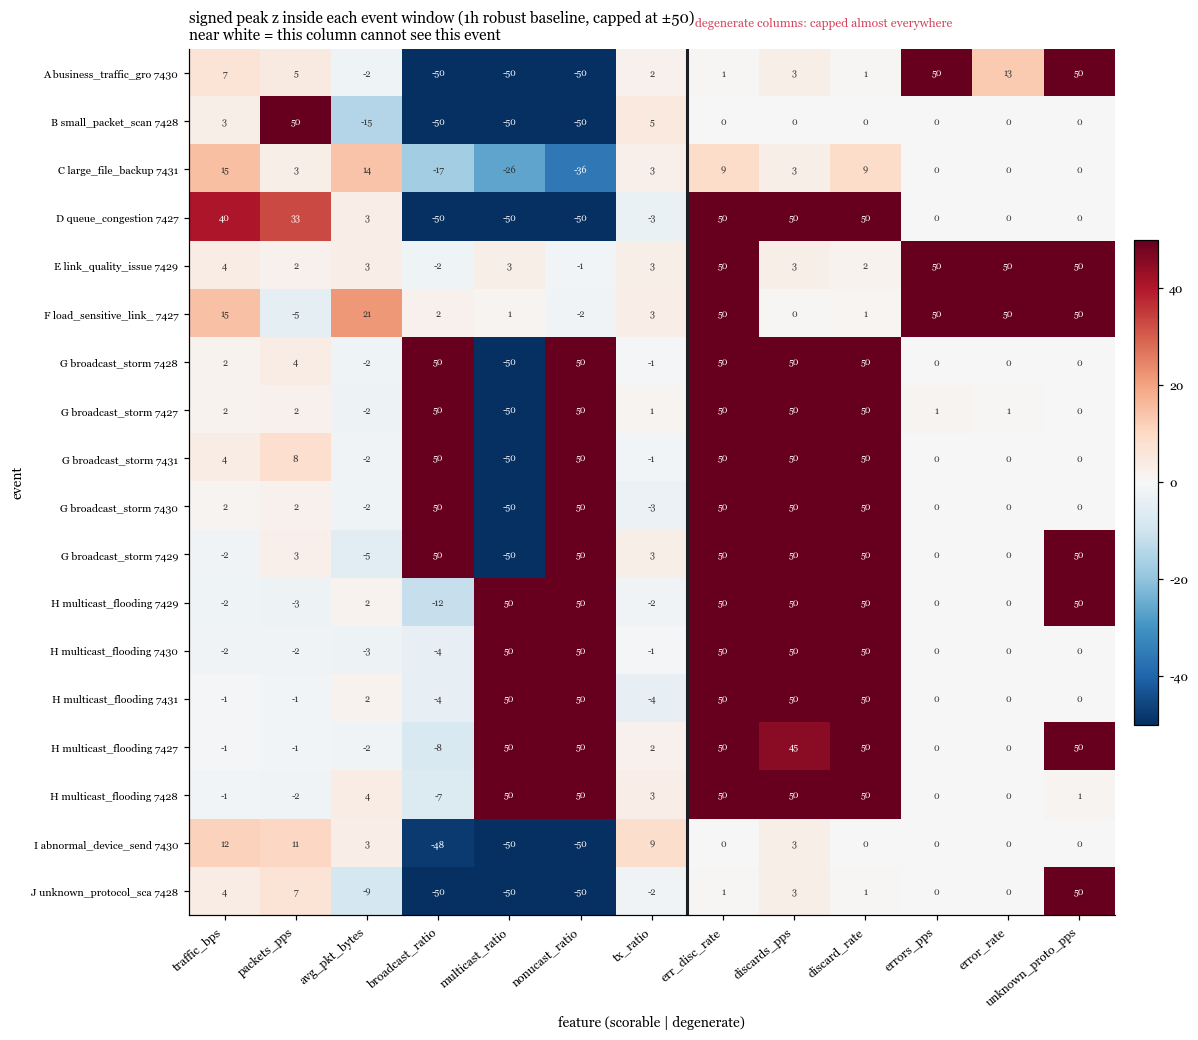

In [20]:
def signed_peak(s):
    """The value furthest from zero inside a window, keeping its sign.

    Sign matters here: broadcast_ratio swinging to +50 and to -50 are different events,
    and an unsigned peak would make them look identical.
    """
    s = s.dropna()
    return float(s.loc[s.abs().idxmax()]) if len(s) else np.nan


# Columns are grouped scorable first, degenerate second, so the two blocks can be read
# against each other: the right-hand block sits at the cap almost everywhere, which is
# what a collapsed denominator looks like rather than a detection.
ORDER = SCORABLE + DEGENERATE
peak = pd.DataFrame([
    {"ev": f"{e.event_id} {e.event_type[:20]} {e.port_id[-4:]}",
     **{c: signed_peak(tel.loc[(tel["port_id"] == e.port_id)
                               & tel["timestamp"].between(e.start, e.end), "z_" + c])
        for c in ORDER}}
    for e in events.itertuples()]).set_index("ev")

fig, ax = plt.subplots(figsize=(11, 0.42 * len(peak) + 2))
im = ax.imshow(peak, cmap="RdBu_r", vmin=-MAX_SCORE, vmax=MAX_SCORE, aspect="auto")
ax.axvline(len(SCORABLE) - 0.5, color="#1B1F23", lw=2.0)
ax.text(len(SCORABLE) - 0.4, -0.9, "degenerate columns: capped almost everywhere",
        fontsize=8, color=C["alert"], va="bottom")
ax.set_xticks(range(len(ORDER)), ORDER, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(len(peak)), peak.index, fontsize=7)
for i in range(peak.shape[0]):
    for j in range(peak.shape[1]):
        ax.text(j, i, f"{peak.iat[i, j]:.0f}", ha="center", va="center", fontsize=6,
                color="white" if abs(peak.iat[i, j]) > 28 else "#333333")
ax.grid(False)
ax.set(xlabel="feature (scorable | degenerate)", ylabel="event",
       title=f"signed peak z inside each event window (1h robust baseline, capped at ±{MAX_SCORE:.0f})\n"
             "near white = this column cannot see this event")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
fig.tight_layout(); plt.show()

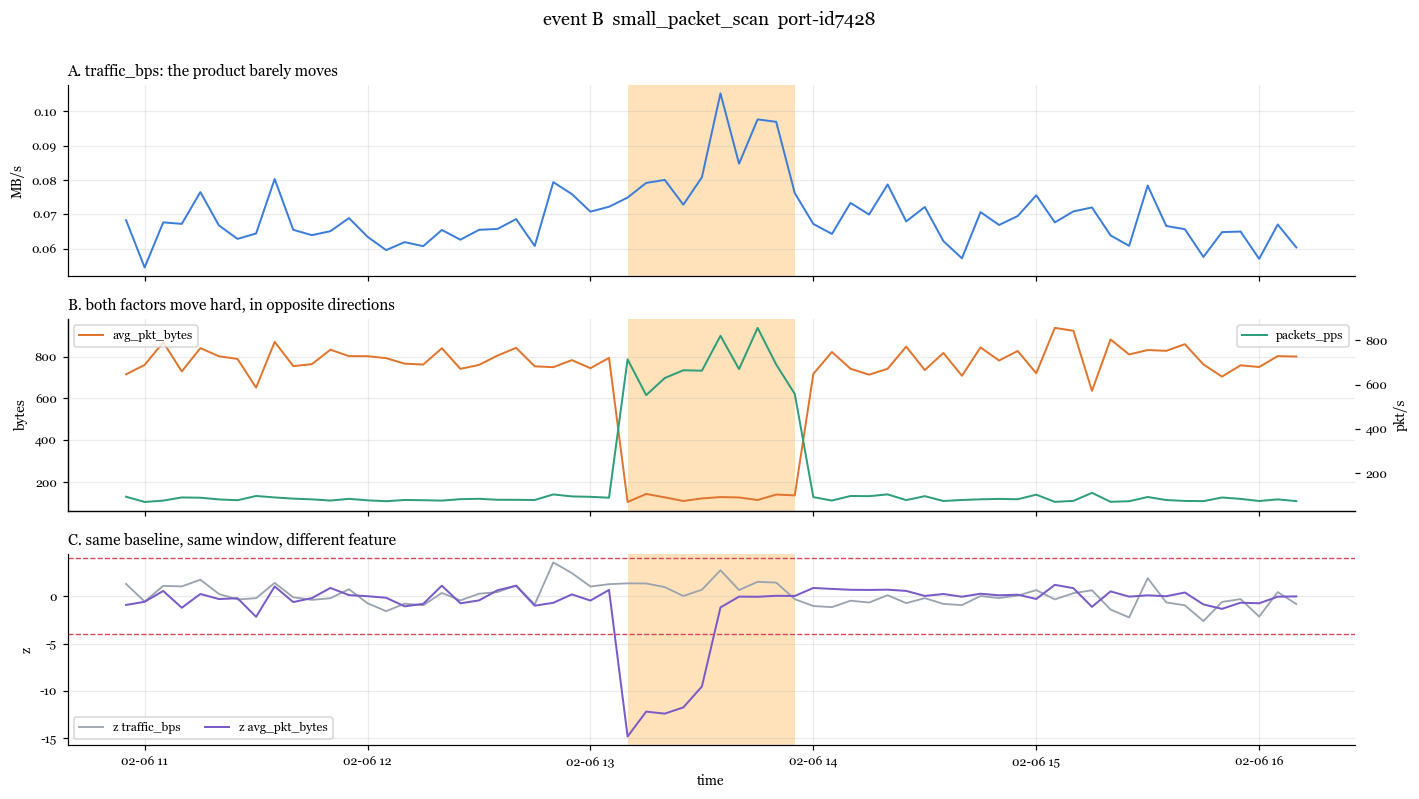

In [21]:
# Event B in close-up. Panel A is the product, panel B its two factors on twin axes,
# panel C the same baseline reading two different features over the same window.
eb = events[events["event_id"] == "B"].iloc[0]
pad = (eb.end - eb.start) * 3                        # show the event with context either side
w = tel[(tel["port_id"] == eb.port_id) & tel["timestamp"].between(eb.start - pad, eb.end + pad)]

fig, axes = plt.subplots(3, 1, figsize=(13, 7.2), sharex=True)
axes[0].plot(w["timestamp"], w["traffic_bps"] / 1e6, color=C["signal"], lw=1.3)
axes[0].set(ylabel="MB/s", title="A. traffic_bps: the product barely moves")

axes[1].plot(w["timestamp"], w["avg_pkt_bytes"], color=C["baseline"], lw=1.3, label="avg_pkt_bytes")
twin = axes[1].twinx(); twin.grid(False)             # the two factors differ by orders of magnitude
twin.plot(w["timestamp"], w["packets_pps"], color=C["peer"], lw=1.3, label="packets_pps")
twin.set_ylabel("pkt/s")
axes[1].set(ylabel="bytes", title="B. both factors move hard, in opposite directions")
axes[1].legend(loc="upper left"); twin.legend(loc="upper right")

axes[2].plot(w["timestamp"], w["z_traffic_bps"], color=C["muted"], lw=1.2, label="z traffic_bps")
axes[2].plot(w["timestamp"], w["z_avg_pkt_bytes"], color=C["score"], lw=1.3, label="z avg_pkt_bytes")
for level in (4, -4):
    axes[2].axhline(level, color=C["alert"], ls="--", lw=0.9)
axes[2].set(ylabel="z", xlabel="time", title="C. same baseline, same window, different feature")
axes[2].legend(loc="lower left", ncol=2)

for ax in axes:
    shade(ax, w["timestamp"], w["is_event"])
fig.suptitle(f"event B  small_packet_scan  {eb.port_id}", y=1.002)
fig.tight_layout(); plt.show()

### 小結

兩個結論，方向相反。

**第一，有一個 event 沒有任何 feature 看得見。** 18 個 window 裡，17 個至少被一個 scorable 欄位以 $|z| > 4$ 標記到，只有 event E（`link_quality_issue`）是 0 個。這一格就是 Lab 02 第 9 步存在的全部理由：那個 event 的訊號在 `errors_pps` 上，而那一欄是 degenerate 的，統計分數在它上面沒有意義。

**第二，三個 ratio 欄位幾乎什麼都看得見。** `broadcast_ratio`、`multicast_ratio`、`nonucast_ratio` 在 18 個 window 裡各命中 16 個，只漏掉 E 與 F。相比之下 `traffic_bps` 命中 5 個、`tx_ratio` 命中 2 個。它們敏感，但不夠 specific：任何讓封包組成改變的事情都會推動這三個比率，所以命中不等於識別。這也解釋了第 14 步為什麼每一欄的 marginal contribution 都是零，因為隨便拿掉哪一欄，這三個都還在。

### 探索練習：換一種「峰值」的定義

**任務**：把 `signed_peak()` 換成「超過 4 的樣本數」。

```python
def signed_peak(s):
    return float((s.abs() > 4).sum())
```

觀察：

- 哪些 event 的排名掉下來了？
- 短而尖的 event 與長而緩的 event，哪一種吃虧？

**討論**：改成數樣本數，衡量的就從「最極端那一瞬間」變成「這個 event 有多持久」。event G 與 H 各佔五列，因為它們同時打在 5 個 port 上。單看 `broadcast_ratio` 那一欄的符號：它不是 broadcast storm 的獨特指紋，其他 event 也會讓這個比率擺到相反的極端，真正識別 G 的是組合。

## 第 14 步：leave-one-out ablation 與 greedy forward selection

固定一組偵測規則：跨 feature 取最大 $|z|$、threshold 4、連續 2 筆確認。先量必須抓到的 window recall，然後一次拿掉一欄再量一次，差值就是那一欄的 **marginal contribution**。

第二個診斷分辨零貢獻的兩種意思：**solo hit** 大於零而 marginal 為零，代表冗餘；兩者皆為零，代表這個月真的什麼都沒抓到。

只在第 8 步判定為 `SCORABLE` 的欄位上跑。degenerate 的欄位 z 幾乎恆定爆表，放進來會用天量 false alarm 換到一個假的滿分，B 圖把那個價碼單獨列出來。

In [22]:
TH, N_CONSEC = 4.0, 2

# Precompute everything the audit loop needs as plain numpy arrays. The loop runs once
# per candidate subset, so anything left as a pandas operation gets paid for many times.
port_arr = tel["port_id"].to_numpy()
ts = tel["timestamp"].to_numpy()
truth = np.zeros(len(tel), bool)                     # True on every sample inside any event
for e in events.itertuples():
    truth |= (port_arr == e.port_id) & (ts >= e.start.to_datetime64()) & (ts <= e.end.to_datetime64())
windows = [np.flatnonzero((port_arr == e.port_id) & (ts >= e.start.to_datetime64())
                          & (ts <= e.end.to_datetime64())) for e in incidents.itertuples()]
days = (tel["timestamp"].max() - tel["timestamp"].min()).total_seconds() / 86400
zabs = {c: np.nan_to_num(tel["z_" + c].abs().to_numpy(), nan=-1.0) for c in FEATURES}


def audit(cols):
    """Score one feature subset: cross-feature max |z|, N-consecutive confirm, then measure.

    Returns (event windows caught, false alarms per day). Recall is counted at window
    level because catching an event once is operationally enough; the cost is counted
    per sample outside any event, because that is what reaches the on-call engineer.
    """
    if not cols:
        return 0, 0.0
    breach = pd.Series(np.vstack([zabs[c] for c in cols]).max(axis=0) > TH)
    ok = np.ones(len(breach), bool)
    for k in range(N_CONSEC):                        # require N consecutive breaches per port
        ok &= breach.groupby(port_arr).shift(k).fillna(False).to_numpy().astype(bool)
    return sum(ok[i].any() for i in windows), ok[~truth].sum() / days


full_recall, full_fp = audit(SCORABLE)

# Leave one out: how much recall disappears, and how much daily noise disappears with it.
abl = pd.DataFrame([{"feature": c,
                     "solo": audit([c])[0],
                     "marginal": full_recall - audit([x for x in SCORABLE if x != c])[0],
                     "fp_added": full_fp - audit([x for x in SCORABLE if x != c])[1]}
                    for c in SCORABLE]).sort_values(["solo", "marginal"]).reset_index(drop=True)

# Greedy forward selection: repeatedly add the column that buys the most recall for the
# least added noise. The curve usually flattens well before the full set is in.
picked, pool, path = [], list(SCORABLE), []
while pool:
    trial = {c: audit(picked + [c]) for c in pool}
    best = max(pool, key=lambda c: (trial[c][0], -trial[c][1]))
    picked.append(best); pool.remove(best)
    path.append({"n": len(picked), "added": best,
                 "recall": trial[best][0], "fp_per_day": trial[best][1]})
path = pd.DataFrame(path)

# What the degenerate columns buy and what they cost. Two different questions, and only
# the second one is about adding them to the set that ships: "solo" is that column on its
# own, "added" is the whole scorable set plus that column. A column can score badly alone
# and still be the only one that sees a particular event.
degen_cost = pd.DataFrame([{"feature": c, "solo": audit([c])[0],
                            "added": audit(SCORABLE + [c])[0],
                            "gain": audit(SCORABLE + [c])[0] - full_recall,
                            "fp_added": audit(SCORABLE + [c])[1] - full_fp}
                           for c in DEGENERATE])

print(f"all {len(SCORABLE)} scorable features: {full_recall}/{len(windows)} incident windows, "
      f"{full_fp:.1f} false alarms/day")

all 7 scorable features: 15/16 incident windows, 10.9 false alarms/day


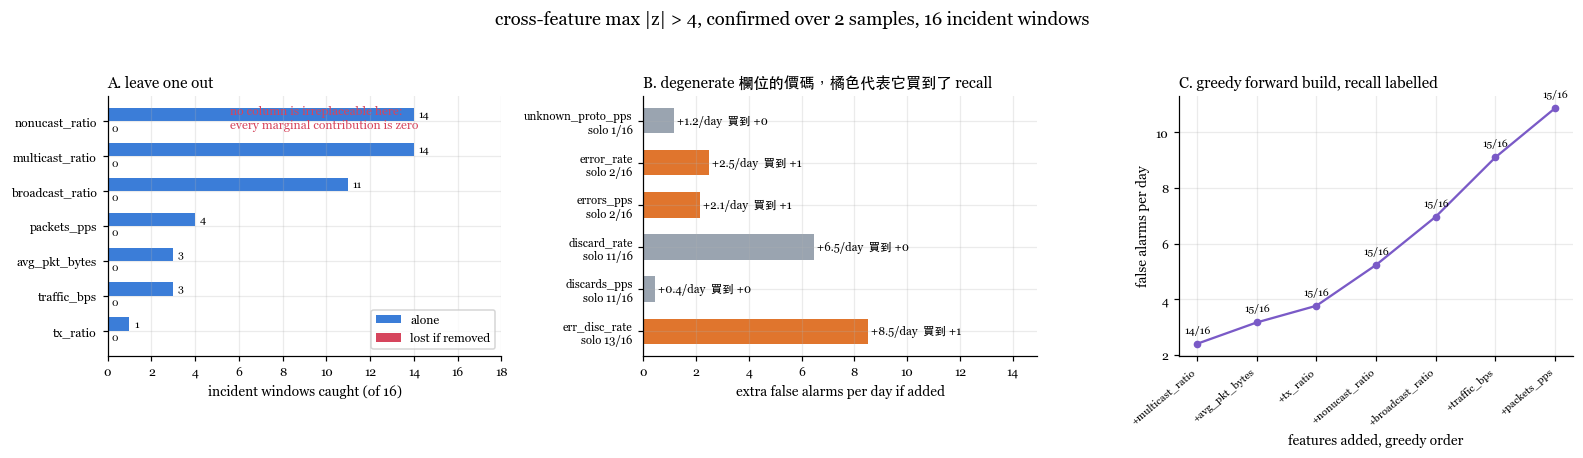

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.0))
y = np.arange(len(abl))
axes[0].barh(y + 0.19, abl["solo"], height=0.38, color=C["signal"], label="alone")
axes[0].barh(y - 0.19, abl["marginal"], height=0.38, color=C["alert"], label="lost if removed")
for n, (solo, marginal) in enumerate(zip(abl["solo"], abl["marginal"])):
    axes[0].text(solo + 0.2, n + 0.19, str(solo), va="center", fontsize=7)
    axes[0].text(marginal + 0.2, n - 0.19, str(marginal), va="center", fontsize=7)
axes[0].set_yticks(y, abl["feature"], fontsize=8)
axes[0].set(xlim=(0, len(windows) + 2), xlabel=f"incident windows caught (of {len(windows)})",
            title="A. leave one out")
axes[0].legend(loc="lower right")
if abl["marginal"].max() == 0:
    # A flat red series is the finding, not a bug: at this threshold every window one
    # column catches is caught by another column too.
    axes[0].text(len(windows) * 0.35, len(abl) - 1.2,
                 "no column is irreplaceable here:\nevery marginal contribution is zero",
                 fontsize=8, color=C["alert"])

axes[1].barh(np.arange(len(degen_cost)), degen_cost["fp_added"],
             color=[C["baseline"] if g > 0 else C["muted"] for g in degen_cost["gain"]],
             height=0.6)
for n, t in enumerate(degen_cost.itertuples()):
    axes[1].text(t.fp_added, n, f" +{t.fp_added:.1f}/day  買到 +{t.gain}", va="center",
                 fontsize=7.5)
axes[1].set_yticks(range(len(degen_cost)),
                   [f"{t.feature}\nsolo {t.solo}/{len(windows)}" for t in degen_cost.itertuples()],
                   fontsize=7.5)
axes[1].set(xlim=(0, degen_cost["fp_added"].max() * 1.75),
            xlabel="extra false alarms per day if added",
            title="B. degenerate 欄位的價碼，橘色代表它買到了 recall")

axes[2].plot(path["n"], path["fp_per_day"], marker="o", ms=4, color=C["score"])
for t in path.itertuples():
    axes[2].annotate(f"{t.recall}/{len(windows)}", (t.n, t.fp_per_day), fontsize=7,
                     textcoords="offset points", xytext=(0, 7), ha="center")
axes[2].set_xticks(path["n"], [f"+{a}" for a in path["added"]], rotation=40, ha="right", fontsize=7)
axes[2].set(xlabel="features added, greedy order", ylabel="false alarms per day",
            title="C. greedy forward build, recall labelled")
fig.suptitle(f"cross-feature max |z| > {TH:.0f}, confirmed over {N_CONSEC} samples, "
             f"{len(windows)} incident windows", y=1.03)
fig.tight_layout(); plt.show()

### 小結

A 圖那一排紅色的零是這一步的第一個結論：**在這組門檻下，scorable 那七欄裡沒有任何一欄是不可替代的。** 第 13 步已經解釋了原因，三個 ratio 欄位各自看得見 18 個 window 中的 16 個，而且漏掉的是同兩個，所以拿掉任何一欄，剩下的還是抓得到。

B 圖的結論方向相反，而且是這一步真正的發現。degenerate 那六欄不是全都沒有用：`errors_pps`、`error_rate`、`err_disc_rate` 三欄把 recall 從 15 推到 16，買到的正是第 13 步唯一漏掉的 event E。價碼從每天多 2.1 則到多 8.5 則不等，最便宜的是 `errors_pps`。

所以「degenerate 的欄位不能用」這句話要講精確一點：**它們不能用 z-score 計分，不代表它們沒有證據。** 證據在，只是這個殼取不出來。Lab 02 給出另外兩條取法，第 9 步用一條固定規則，第 11 到 13 步用不需要逐欄估 scale 的模型，兩條路的價碼都比這裡便宜。

C 圖顯示前兩欄就拿到了 scorable 這條路的 recall 上限，之後每加一欄只增加每日 false alarm。

這一步的貢獻是把「這個 feature 有用嗎」換成一個有單位的問題：它每天值多少則 alert。

### 探索練習：ablation 的判定門檻

**任務**：把 `TH` 改成 3.0、`N_CONSEC` 改成 3，重新執行這兩格。

```python
TH, N_CONSEC = 3.0, 3
```

觀察：

- 哪幾欄的 marginal contribution 變了？
- B 圖裡買得到 recall 的還是同樣那三欄嗎？價碼變多少？

**討論**：如果一個 feature 的價值取決於 threshold 怎麼設，那它的「貢獻」到底是什麼意思？跨 feature 目前取 `max`，換成加權平均或投票會得到另一組結論，而 `max` 正是讓 degenerate 欄位變貴的原因，因為它讓任何一欄的爆表獨自決定整個分數。greedy forward selection 只走一條路徑，窮舉所有子集才是完整的核算。selection 也是把五個 port 混在一起選的，不同 role 的 port 最佳組合不一定相同。

## 第 15 步：anomaly taxonomy

| 形狀 | 訊號長什麼樣 | 本資料集的例子 | 誰來修 |
|---|---|---|---|
| Point | 單一讀數遠離線條 | D `queue_congestion` | 任何 baseline |
| Contextual | 選對 feature 才顯得不尋常 | B `small_packet_scan` | feature selection（本 lab） |
| Collective | 沒有單點極端，群體一起動 | G `broadcast_storm` | feature 加上跨指標推理 |
| Change point | 水位本身永久移動 | A `business_traffic_growth` | change-point detection（Lab 02） |

Contextual 與 collective 由 feature 解決，不是由更精細的 baseline 解決。一個只調 baseline 的 pipeline，對這張表上大約一半的 anomaly 結構性地盲目。

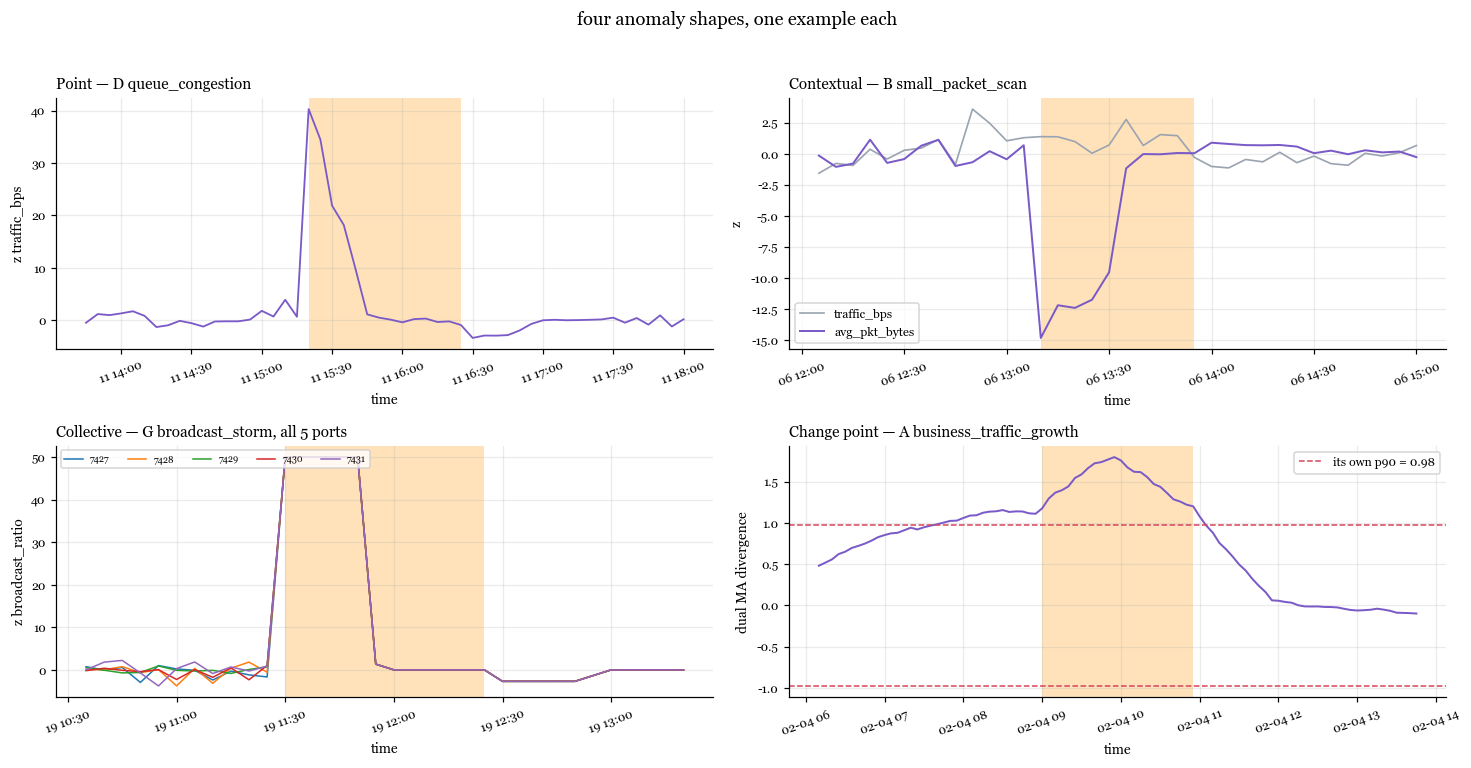

In [24]:
def dual_ma(v, short, long):
    """Change-point statistic: relative gap between a fast and a slow moving average.

    A stable series keeps the two averages together. A level shift makes the fast one
    move first, and the gap between them is the signal. This asks a different question
    from a z-score: not how far this sample sits from the level, but whether the level moved.
    """
    fast = v.rolling(short, min_periods=short // 2).mean()
    slow = v.rolling(long, min_periods=long // 2).mean()
    return (fast - slow) / (slow.abs() + 1e-9)


def window_of(e, pad_mult=1.5):
    """Rows for one event plus context on both sides, so the run-up is visible."""
    pad = (e.end - e.start) * pad_mult
    return tel[(tel["port_id"] == e.port_id) & tel["timestamp"].between(e.start - pad, e.end + pad)]


fig, axes = plt.subplots(2, 2, figsize=(13.5, 6.8))

ed = events[events.event_id == "D"].iloc[0]
w = window_of(ed)
axes[0, 0].plot(w["timestamp"], w["z_traffic_bps"], color=C["score"], lw=1.2)
axes[0, 0].set(ylabel="z traffic_bps", title="Point — D queue_congestion")

# Contextual: the same window read through two features, one blind and one not.
eb = events[events.event_id == "B"].iloc[0]
w = window_of(eb)
axes[0, 1].plot(w["timestamp"], w["z_traffic_bps"], color=C["muted"], lw=1.1, label="traffic_bps")
axes[0, 1].plot(w["timestamp"], w["z_avg_pkt_bytes"], color=C["score"], lw=1.3, label="avg_pkt_bytes")
axes[0, 1].legend(loc="lower left")
axes[0, 1].set(ylabel="z", title="Contextual — B small_packet_scan")

# Collective: no single port is an outlier against its peers, they all move together.
g = events[events.event_id == "G"]
g0, g1 = g["start"].min(), g["end"].max()
for pid in ports:
    w = tel[(tel["port_id"] == pid) & tel["timestamp"].between(g0 - (g1 - g0), g1 + (g1 - g0))]
    axes[1, 0].plot(w["timestamp"], w["z_broadcast_ratio"], lw=1.0, label=pid[-4:])
axes[1, 0].axvspan(g0, g1, color=C["truth"], alpha=0.3, lw=0)
axes[1, 0].legend(fontsize=6, ncol=5, loc="upper left")
axes[1, 0].set(ylabel="z broadcast_ratio", title="Collective — G broadcast_storm, all 5 ports")

# Change point: the threshold comes from the series' own history, not from elsewhere.
ea = events[events.event_id == "A"].iloc[0]
cp = tel[tel["port_id"] == ea.port_id].sort_values("timestamp").copy()
cp["dual_ma"] = dual_ma(cp["traffic_bps"], WINDOW, 6 * WINDOW)
pad = (ea.end - ea.start) * 1.5
w = cp[cp["timestamp"].between(ea.start - pad, ea.end + pad)]
axes[1, 1].plot(w["timestamp"], w["dual_ma"], color=C["score"], lw=1.3)
p90 = cp["dual_ma"].abs().quantile(0.9)
axes[1, 1].axhline(p90, color=C["alert"], ls="--", lw=1.0, label=f"its own p90 = {p90:.2f}")
axes[1, 1].axhline(-p90, color=C["alert"], ls="--", lw=1.0)
axes[1, 1].legend()
axes[1, 1].set(ylabel="dual MA divergence", title="Change point — A business_traffic_growth")

for ax, e in zip([axes[0, 0], axes[0, 1], axes[1, 1]], [ed, eb, ea]):
    ax.axvspan(e.start, e.end, color=C["truth"], alpha=0.3, lw=0)
for ax in axes.flat:
    ax.set_xlabel("time"); ax.tick_params(axis="x", labelrotation=20)
fig.suptitle("four anomaly shapes, one example each", y=1.02)
fig.tight_layout(); plt.show()

### 小結

四格圖的用途是把前面十步的結果對應到「該修哪一層」。左上與右上是同一個 baseline、同一個門檻，差別只在餵進去的 feature，右上那格 `traffic_bps` 全程貼近零而 `avg_pkt_bytes` 掉到 -15。左下五條線一起動，所以任何「跟同儕比」的方法在這裡結構性地失效，這是 Lab 02 第 2 步 peer baseline 的已知盲點。

右下與其他三格問的不是同一個問題。點偏差的分數在 event 開始後很快回到零，因為 baseline 追上了新水位；雙移動平均的差距這時才到峰值。

這一步不產生任何下游用得到的欄位，它的貢獻是診斷順序：先確認 feature 承載了訊號，再談 baseline。順序反過來，contextual 與 collective 這兩類永遠調不出來。

### 探索練習：change point 的兩個 window

**任務**：把 `dual_ma` 的 `long` 從 `6 * WINDOW` 改成 `24 * WINDOW`。

```python
cp["dual_ma"] = dual_ma(cp["traffic_bps"], WINDOW, 24 * WINDOW)
```

觀察：

- 訊號更乾淨還是更遲鈍？
- p90 這條線跟著往哪個方向移動？

**討論**：這張分類表決定的是「哪一層該修」。contextual 與 collective 要回到 feature，point 與 change point 才輪到 baseline，搞錯層級，調再久的 baseline 也不會動。

## 第 16 步：存檔與 feature spec 版本化

寫兩個檔案。`features.csv` 是資料，`feature_spec.json` 是讀這份資料需要知道的事。

分成兩份是因為它們的變更頻率不同。資料每天長，spec 只在你改了設計的時候才動。而在此之前，`SCORABLE` 與 `DEGENERATE` 這兩份名單只印在畫面上，Lab 02 靠人抄一份寫死的 list 過去，第 8 步的界線一改，Lab 02 不會知道，也不會有任何一格跳出錯誤。

spec 裡放三類東西：量出來的資料契約（cadence、window、base rate）、設計決定（哪些欄位可計分、界線設在哪）、以及產生它的參數。baseline 的 center 與 scale 仍然不寫出去，因為重算它們正是 Lab 02 的主題。

/Users/kevin/Library/CloudStorage/GoogleDrive-kevin880987@gmail.com/我的雲端硬碟/workshop/workbench/project/202608-aia-network-monitoring-aiops/aiops-anomaly-zero-to-hero/outputs/workshop/features.csv  (9.9 MB)  43,200 rows x 33 columns
/Users/kevin/Library/CloudStorage/GoogleDrive-kevin880987@gmail.com/我的雲端硬碟/workshop/workbench/project/202608-aia-network-monitoring-aiops/aiops-anomaly-zero-to-hero/outputs/workshop/feature_spec.json  (1.7 kB)

{
  "volume": [
    "traffic_bps",
    "packets_pps",
    "errors_pps",
    "discards_pps",
    "unknown_proto_pps"
  ],
  "shape": [
    "avg_pkt_bytes",
    "broadcast_ratio",
    "multicast_ratio",
    "nonucast_ratio",
    "tx_ratio",
    "error_rate",
    "discard_rate",
    "err_disc_rate"
  ],
  "scorable": [
    "traffic_bps",
    "packets_pps",
    "avg_pkt_bytes",
    "broadcast_ratio",
    "multicast_ratio",
    "nonucast_ratio",
    "tx_ratio"
  ],
  "degenerate": [
    "err_disc_rate",
    "discards_pps",
    "discard_rate",
    "errors_pp

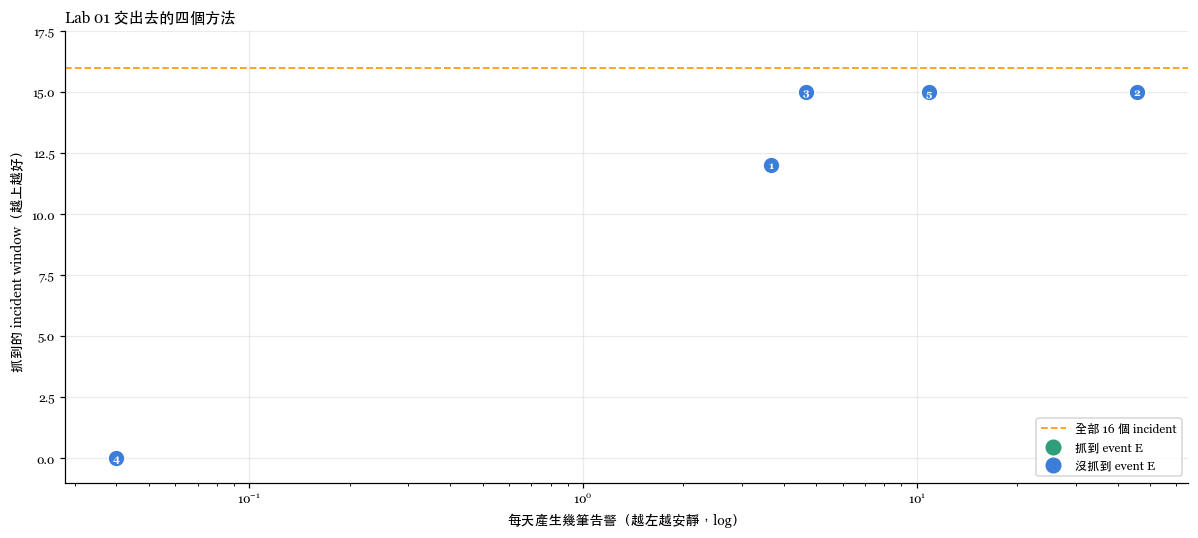

,方法,抓到,每日筆數,延遲(分),抓到E
1,兩欄，未平滑,12,3.67,5.0,False
2,兩欄，中位數濾波 k=9,15,45.71,5.0,False
3,兩欄，聚合成 30 分鐘,15,4.67,25.0,False
4,rolling mean z，7 欄,0,0.00,NaN,False
5,robust z，7 欄,15,10.87,5.0,False


,name,threshold,recall,of,labels_per_day,median_delay_min,caught_E
1,兩欄，未平滑,4.0,12,16,3.67,5.0,False
2,兩欄，中位數濾波 k=9,4.0,15,16,45.71,5.0,False
3,兩欄，聚合成 30 分鐘,4.0,15,16,4.67,25.0,False
4,rolling mean z，7 欄,4.0,0,16,0.00,NaN,False
5,robust z，7 欄,4.0,15,16,10.87,5.0,False


In [25]:
keep = (["timestamp", "device_id", "port_id", "port_role", "event_label", "event_id", "is_event"]
        + FEATURES + [f"z_{c}" for c in FEATURES])
out = OUT / "features.csv"
tel[keep].to_csv(out, index=False, float_format="%.6g")

# Everything Lab 02 would otherwise have to re-derive or hard-code. The zero_fraction map is
# kept in full rather than just the two lists, so a reader can see how close each column sat
# to the boundary instead of trusting that 0.5 was a safe place to put it.
spec = {
    "produced_by": "labs/workshop/01_time_series_features.ipynb",
    "data_contract": {
        "rows": int(len(tel)),
        "ports": sorted(tel["port_id"].unique().tolist()),
        "cadence_seconds": CADENCE,
        "window_samples": WINDOW,
        "day_samples": DAY,
        "span_days": round((tel["timestamp"].max() - tel["timestamp"].min()).total_seconds()
                           / 86400, 2),
        "base_rate": round(BASE_RATE, 6),
        "shortest_event_samples": int(events.n.min()),
    },
    "features": {
        "volume": VOLUME,
        "shape": SHAPE,
        "scorable": SCORABLE,
        "degenerate": DEGENERATE,
        "zero_fraction": {c: round(float(zero_frac[c]), 4) for c in FEATURES},
    },
    "baseline": {
        "estimator": "rolling median / MAD",
        "mad_to_sigma": MAD_TO_SIGMA,
        "score_cap": MAX_SCORE,
        "scale_floor_fraction": 0.05,
        "degenerate_zero_fraction_cutoff": 0.5,
    },
}
spec_path = OUT / "feature_spec.json"
spec_path.write_text(json.dumps(spec, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"{out}  ({out.stat().st_size / 1e6:.1f} MB)  {len(tel):,} rows x {len(keep)} columns")
print(f"{spec_path}  ({spec_path.stat().st_size / 1e3:.1f} kB)")
print()
print(json.dumps(spec["features"] | {"zero_fraction": "..."}, indent=2, ensure_ascii=False))
print(f"\nLab 02 讀 spec 而不是抄名單，第 8 步的界線一改，下游自動跟著改。")

pd.DataFrame(LEDGER).to_csv(LEDGER_PATH, index=False)
print(f"ledger 寫出 {len(LEDGER)} 個方法 -> {LEDGER_PATH}")

plot_ledger(title="Lab 01 交出去的四個方法")

### 小結

13 欄 feature 加 13 欄 z，加識別欄，寫成一份不到 10 MB 的 CSV，旁邊一份幾 kB 的 spec。

`SCORABLE` 與 `DEGENERATE` 現在是檔案裡的欄位，不是印在畫面上要人抄過去的名單。Lab 02 第 1 步讀 spec，所以第 8 步的界線改了，下游會跟著改，而不是安靜地繼續用舊名單。

### 探索練習：契約要涵蓋到哪裡

**任務**：把 `degenerate_zero_fraction_cutoff` 從 0.5 改成 0.3，重新執行第 8 步與這一格，然後直接執行 Lab 02 的第 1 步。

```python
DEGENERATE = zero_frac[zero_frac > 0.3].index.tolist()
```

觀察：

- `feature_spec.json` 裡的 `scorable` 少了哪幾欄？
- Lab 02 印出來的 feature 數量跟著變了嗎？

**討論**：spec 現在記錄了選擇，但它沒有記錄選擇的時間，也沒有版本編號。兩個月後的 `features.csv` 用哪一版 spec 產生的，目前分不出來。最小的補法是加一個 `spec_version` 與產生時間，再把兩者一起寫進 CSV 的檔名。更完整的做法是把 spec 的 hash 寫進每一列，代價是檔案變大，而好處是任何一列都能追回它是用哪一套規則算出來的。

## 人類驗證點 #1：feature 由你設計

本 lab 裡的每一個 feature、`WINDOW` 的長度、degenerate 的 0.5 界線，都是由你設計的，不是演算法自動選出來的。

**任何 feature 演算法都算得出來，但它不知道哪些 feature 對你的網路有意義。**

在繼續之前，問自己四件事：

1. 你選的 `WINDOW`（1 小時）適合你的業務節奏嗎？24/7 的資料中心和朝九晚五的辦公室網路，baseline 的形狀完全不同。第 10 步的 autocorrelation 給了下限，上限要由你決定。
2. `error_rate = errors / packets` 這個公式合理嗎？如果某個 port 幾乎沒有流量，分母趨近於零會發生什麼？Lab 02 的 minimum volume gate 就是為了這個。
3. 第 14 步說有幾欄的 marginal contribution 是零。你會把它們刪掉，還是留著？留著的理由是什麼，這個理由是誰在什麼時候會重新檢視？
4. 第 1 步把 18 個 window 切成「必須抓到」與「必須安靜」兩堆。你的環境裡那份 change calendar 存在嗎，還是抑制的決定散落在每個人的記憶裡？

這些判斷要由你來做。

## 練習與檢查點

完成本 lab 後，你應該能回答四個問題：

1. 把第 11 步的 `ev` 從 event D 換成 event C，重新執行。rolling mean 與 rolling robust 的差距變大還是變小？為什麼？
2. `avg_pkt_bytes` 升高通常代表什麼業務行為？降低呢？（提示：大量小封包與少量大封包的差異）
3. 為什麼 rolling statistics 必須逐 port 獨立計算，而不能把五個 port 混在一起？
4. 第 13 步證明了 event B 對 `traffic_bps` 不可見。用同樣的邏輯，想一個對 `avg_pkt_bytes` 也不可見的故障形狀。

---

> 「`floor_of()` 解決了什麼問題？如果不用它，哪一欄的 score 最先失控？」

> 「為什麼 `tx_ratio` 可能在半夜出現極端值，即使網路完全正常？」

> 「如果你的網路有明顯的上班與下班流量模式，1 小時 window 與 1 天 window 各有什麼問題？」

## 結論

這一節做完之後手上握著三樣東西，Lab 02 全部要用：

1. 一組候選 feature，以及量出來的 marginal contribution 與每日 false alarm 代價。
2. 兩個結構性缺口。contextual 與 collective anomaly 靠 feature 解決，degenerate 的欄位靠 fixed threshold 解決，而 Lab 02 第 13 步會證明還有第三條路。
3. 一份機器讀得懂的資料契約：cadence、1 小時 window 的樣本數、base rate 0.66%、最短 event 8 筆，以及哪些欄位可計分。最後兩個數字分別限制 Lab 02 的 confirmation 長度與可用的 score 欄位。

前五步做的是投影片上第 4 與第 5 格，也就是清理與聚合。這一段沒有改動任何一個數字，它做的事是證明不需要改動：沒有重複、沒有缺口、雜訊小到不值得平滑、而 30 分鐘以內的聚合不損失 recall。**這個結論本身要靠量出來，而不是靠假設乾淨。**

**下一步 → Lab 02：異常偵測、模型與告警。**